AIM :  The goal is to analyze global pollution data and develop strategies for pollution reduction and converting pollutants into energy. The dataset will be used for both data preprocessing and building regression models to predict energy recovery from pollution levels.

Step 1 - Data Import and Preprocessing


In [254]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [255]:
df = pd.read_csv('Global_Pollution_Analysis.csv')

In [256]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [257]:
df.shape

(200, 13)

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

NO - NULL 

In [259]:
(df == "").sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [260]:
df.duplicated().sum()

np.int64(0)

In [261]:
df_new = df.copy()

In [262]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])

     

In [263]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new['Country'] = le.fit_transform(df['Country'])
df_new['Year'] = le.fit_transform(df['Year'])
     

In [264]:
df_new.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,92,4,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,11,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,41,10,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


In [265]:
df.sort_values(by='Year')['Year']

14     2000
10     2000
25     2000
39     2000
42     2000
       ... 
62     2019
169    2019
132    2019
131    2019
157    2019
Name: Year, Length: 200, dtype: int64

So data is from year 2000 to 2019 

Step 2 - Exploratory Data Analysis (EDA)


In [266]:
df_new.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [267]:
# df.describe().corr()

In [268]:
correlation = df_new.corr(numeric_only=True)["Energy_Recovered (in GWh)"]
correlation

Country                                  -0.044316
Year                                      0.088332
Air_Pollution_Index                       0.002997
Water_Pollution_Index                    -0.041828
Soil_Pollution_Index                      0.064076
Industrial_Waste (in tons)               -0.161309
Energy_Recovered (in GWh)                 1.000000
CO2_Emissions (in MT)                     0.024758
Renewable_Energy (%)                      0.043533
Plastic_Waste_Produced (in tons)         -0.072946
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Population (in millions)                 -0.075100
GDP_Per_Capita (in USD)                   0.004535
Name: Energy_Recovered (in GWh), dtype: float64

<Axes: >

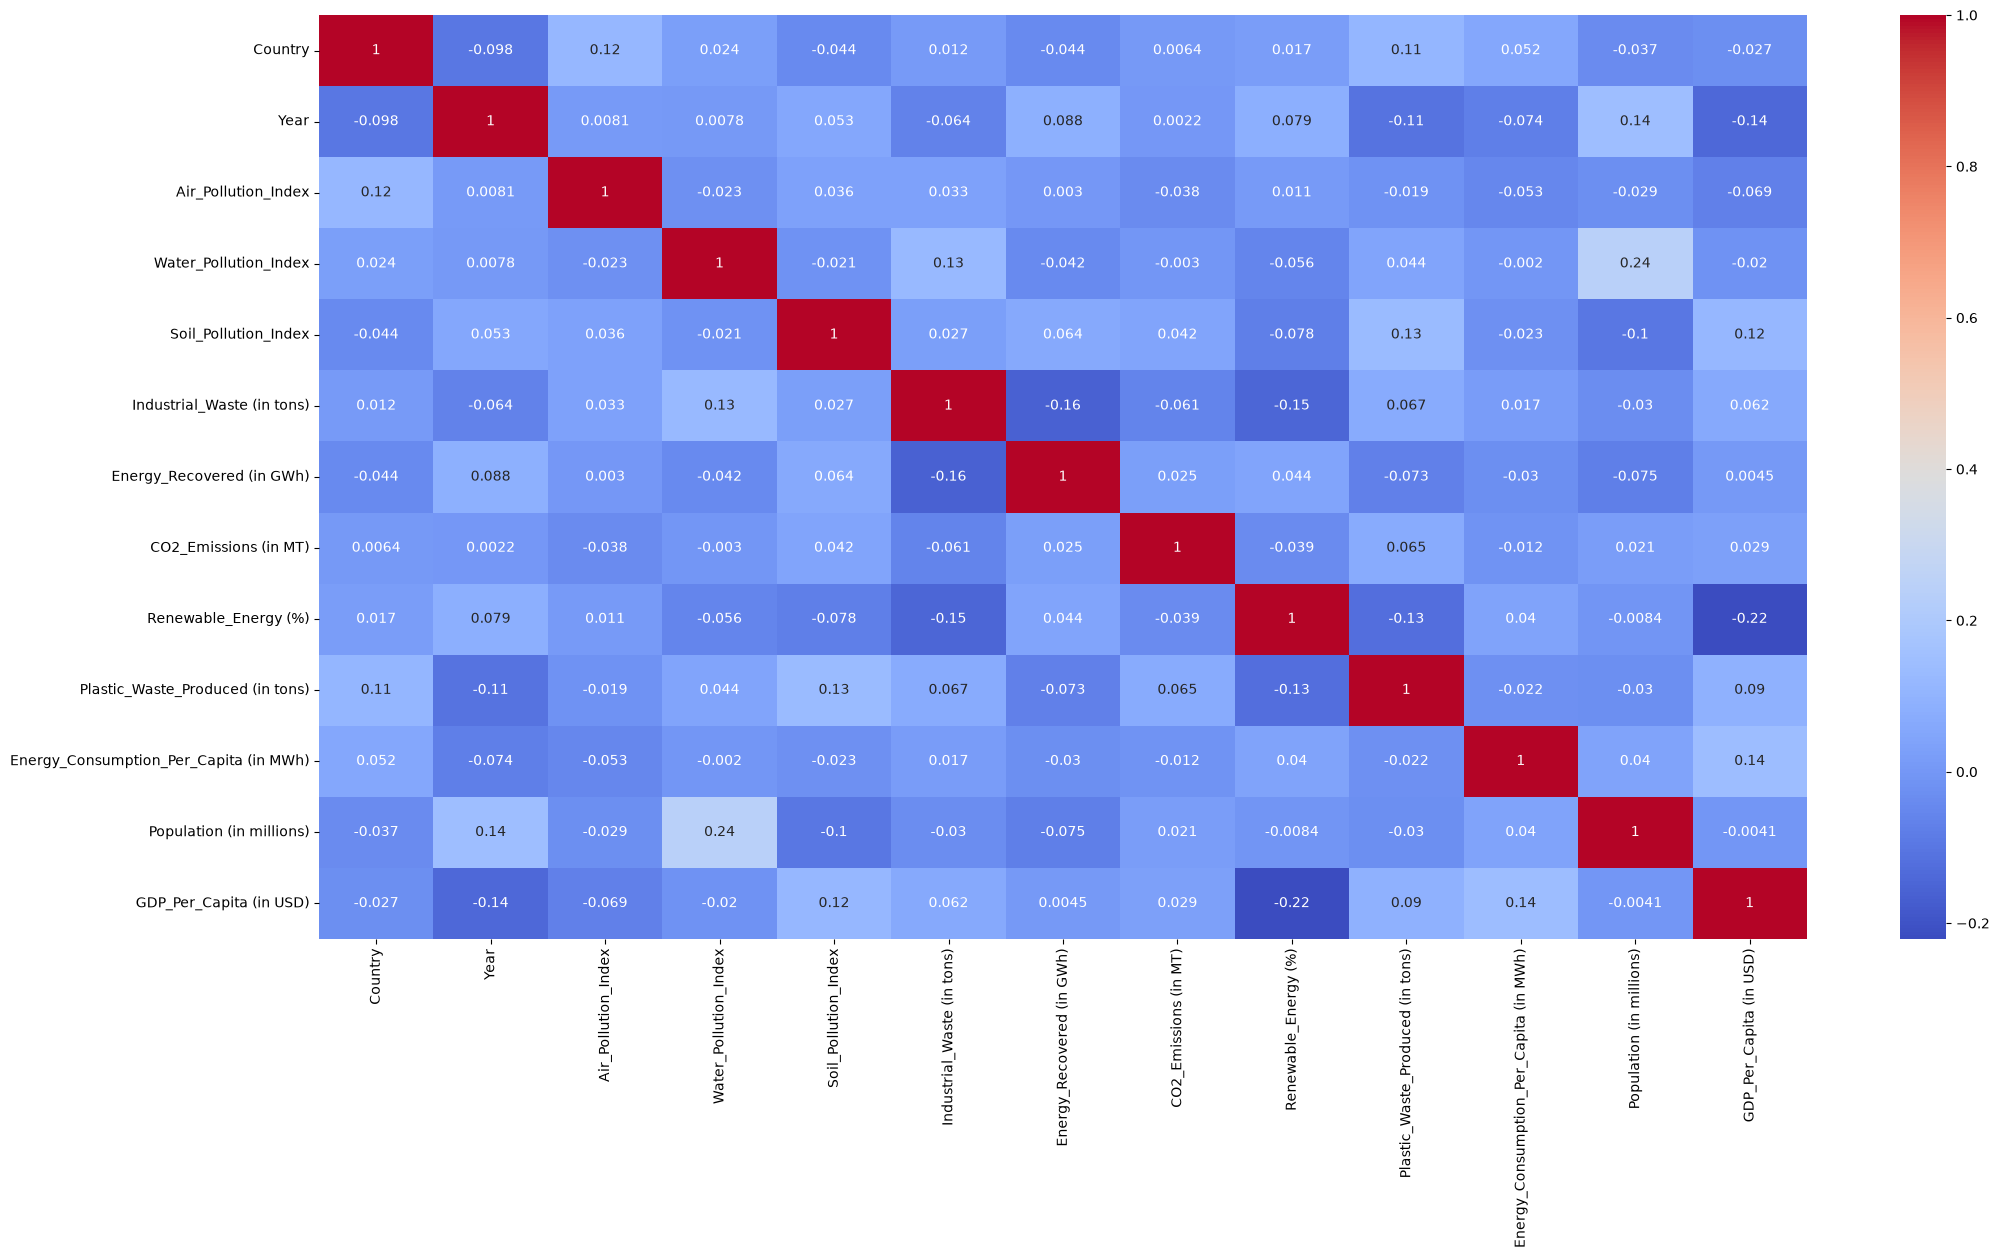

In [269]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True ,cmap = "coolwarm")

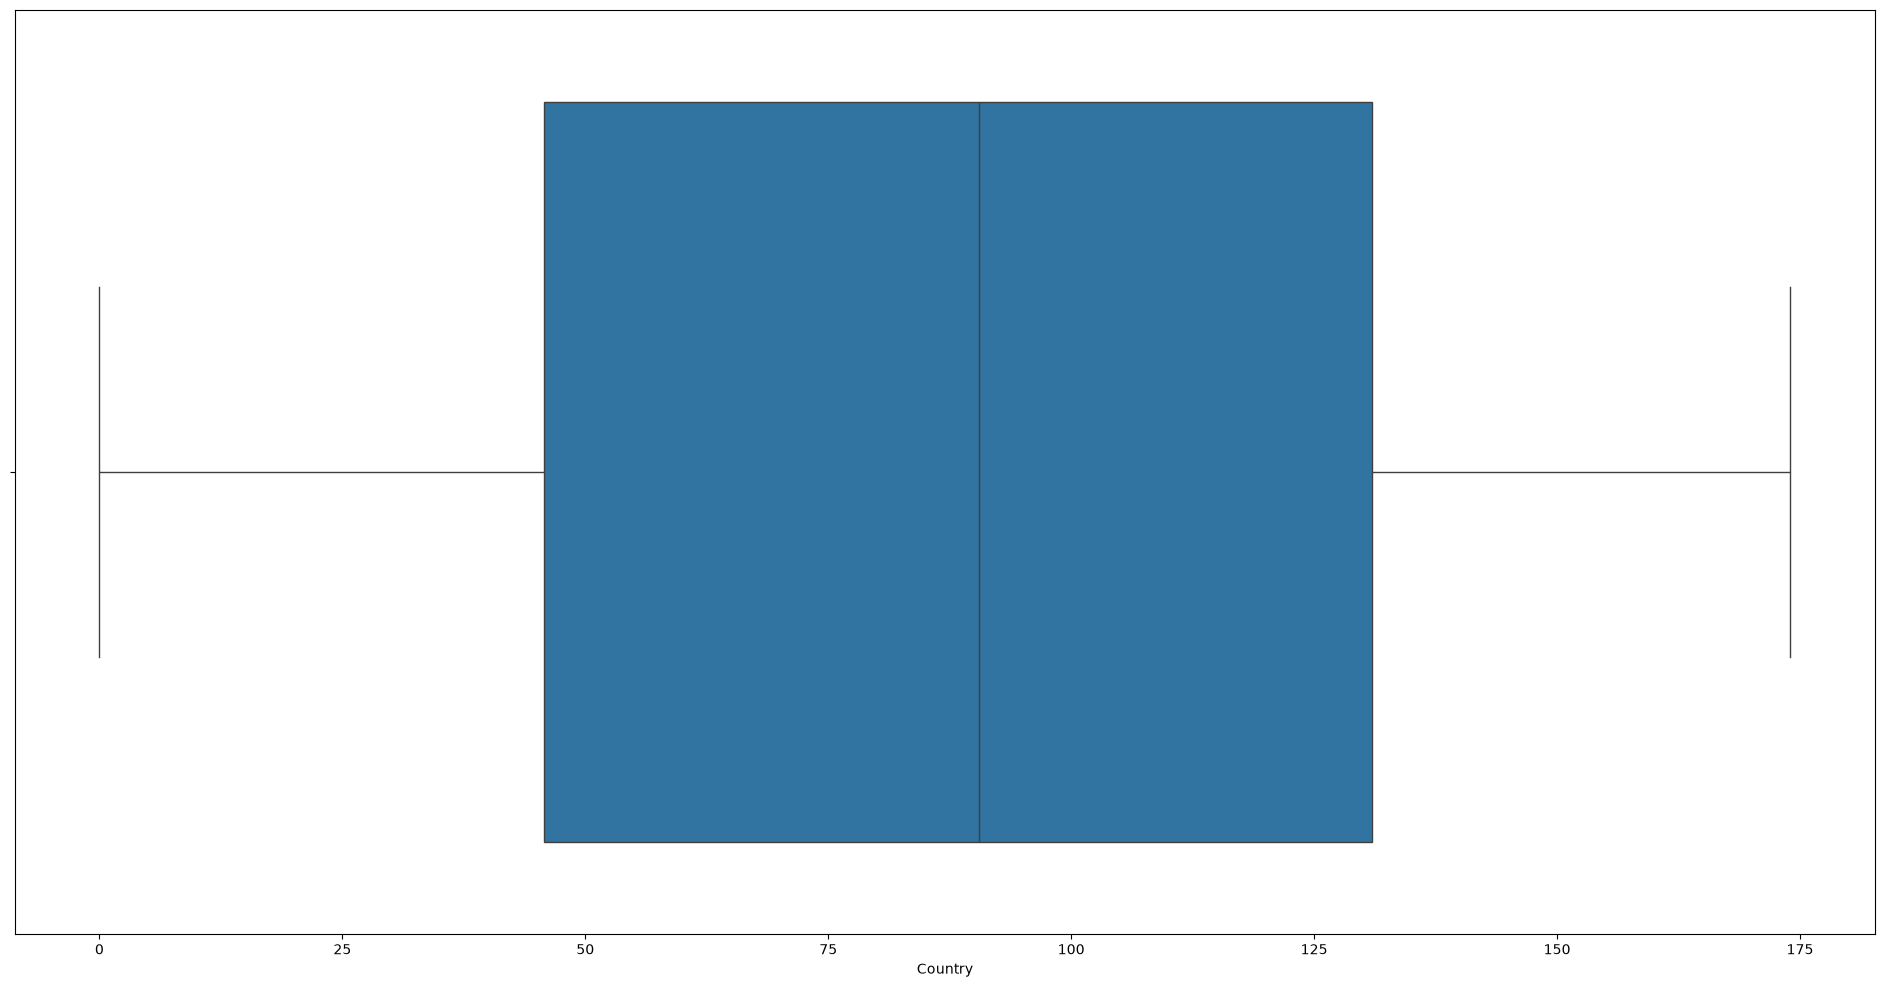

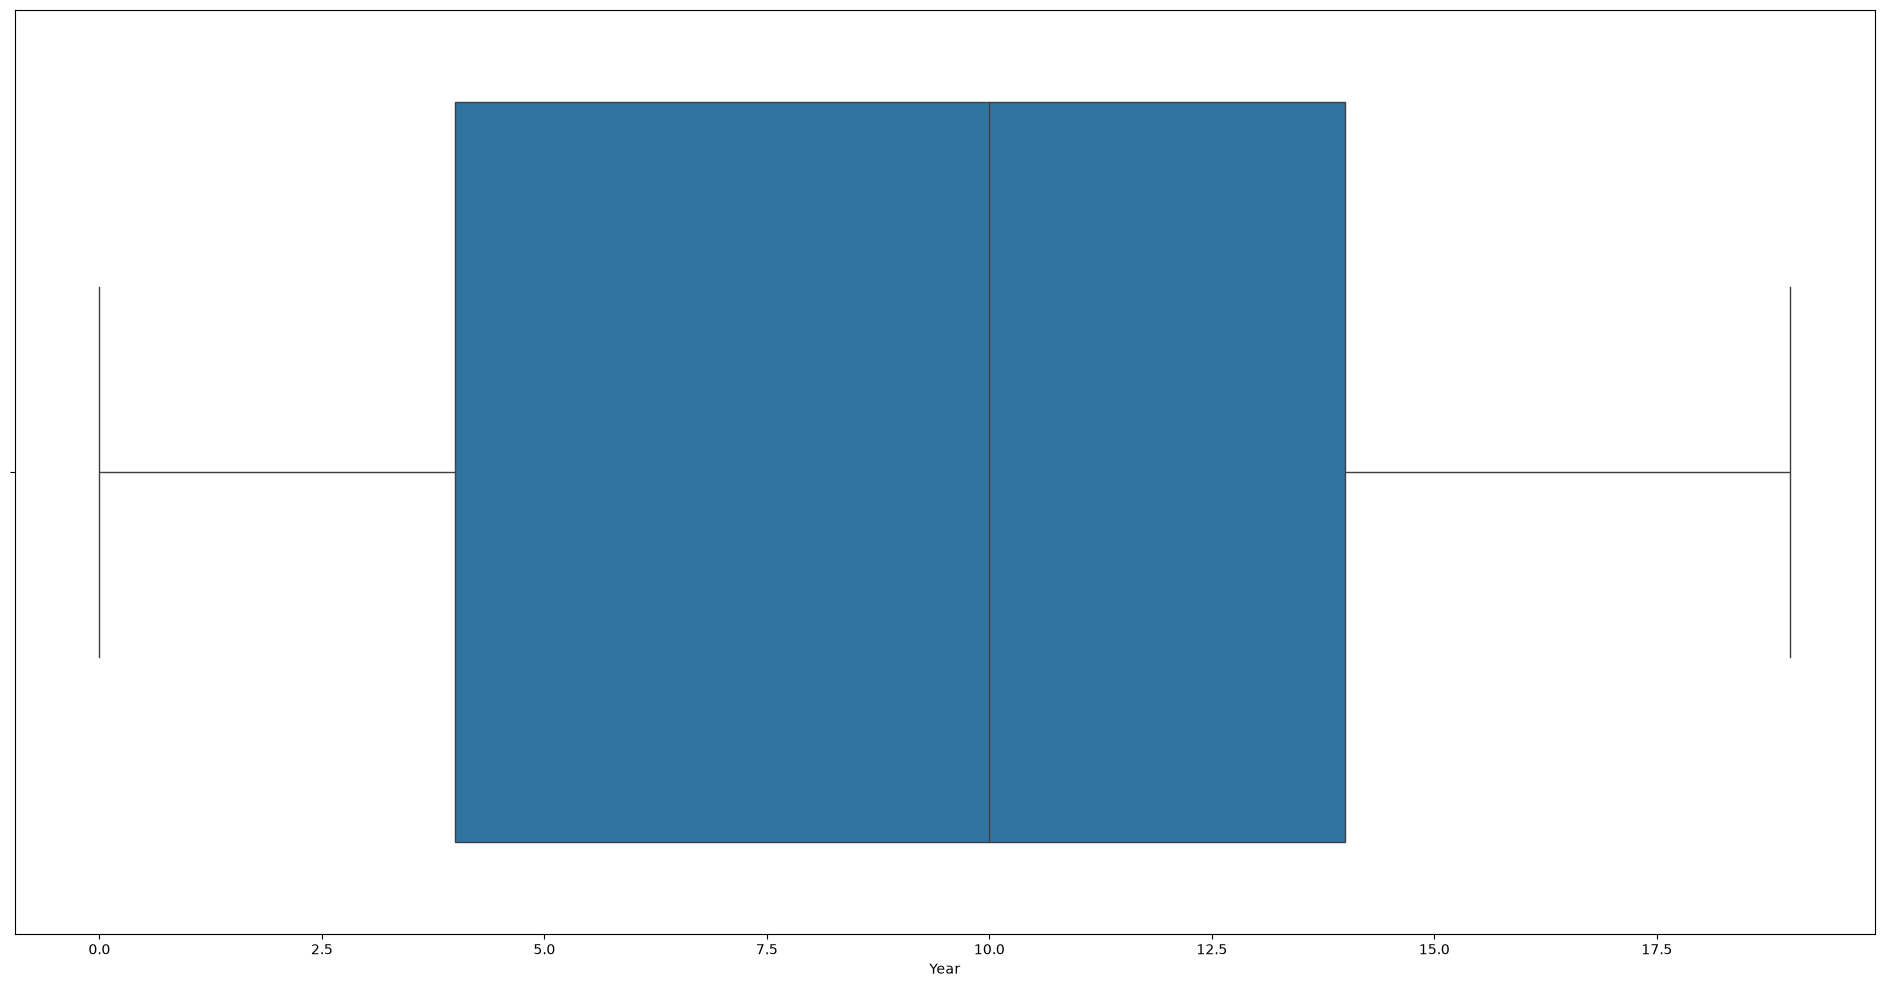

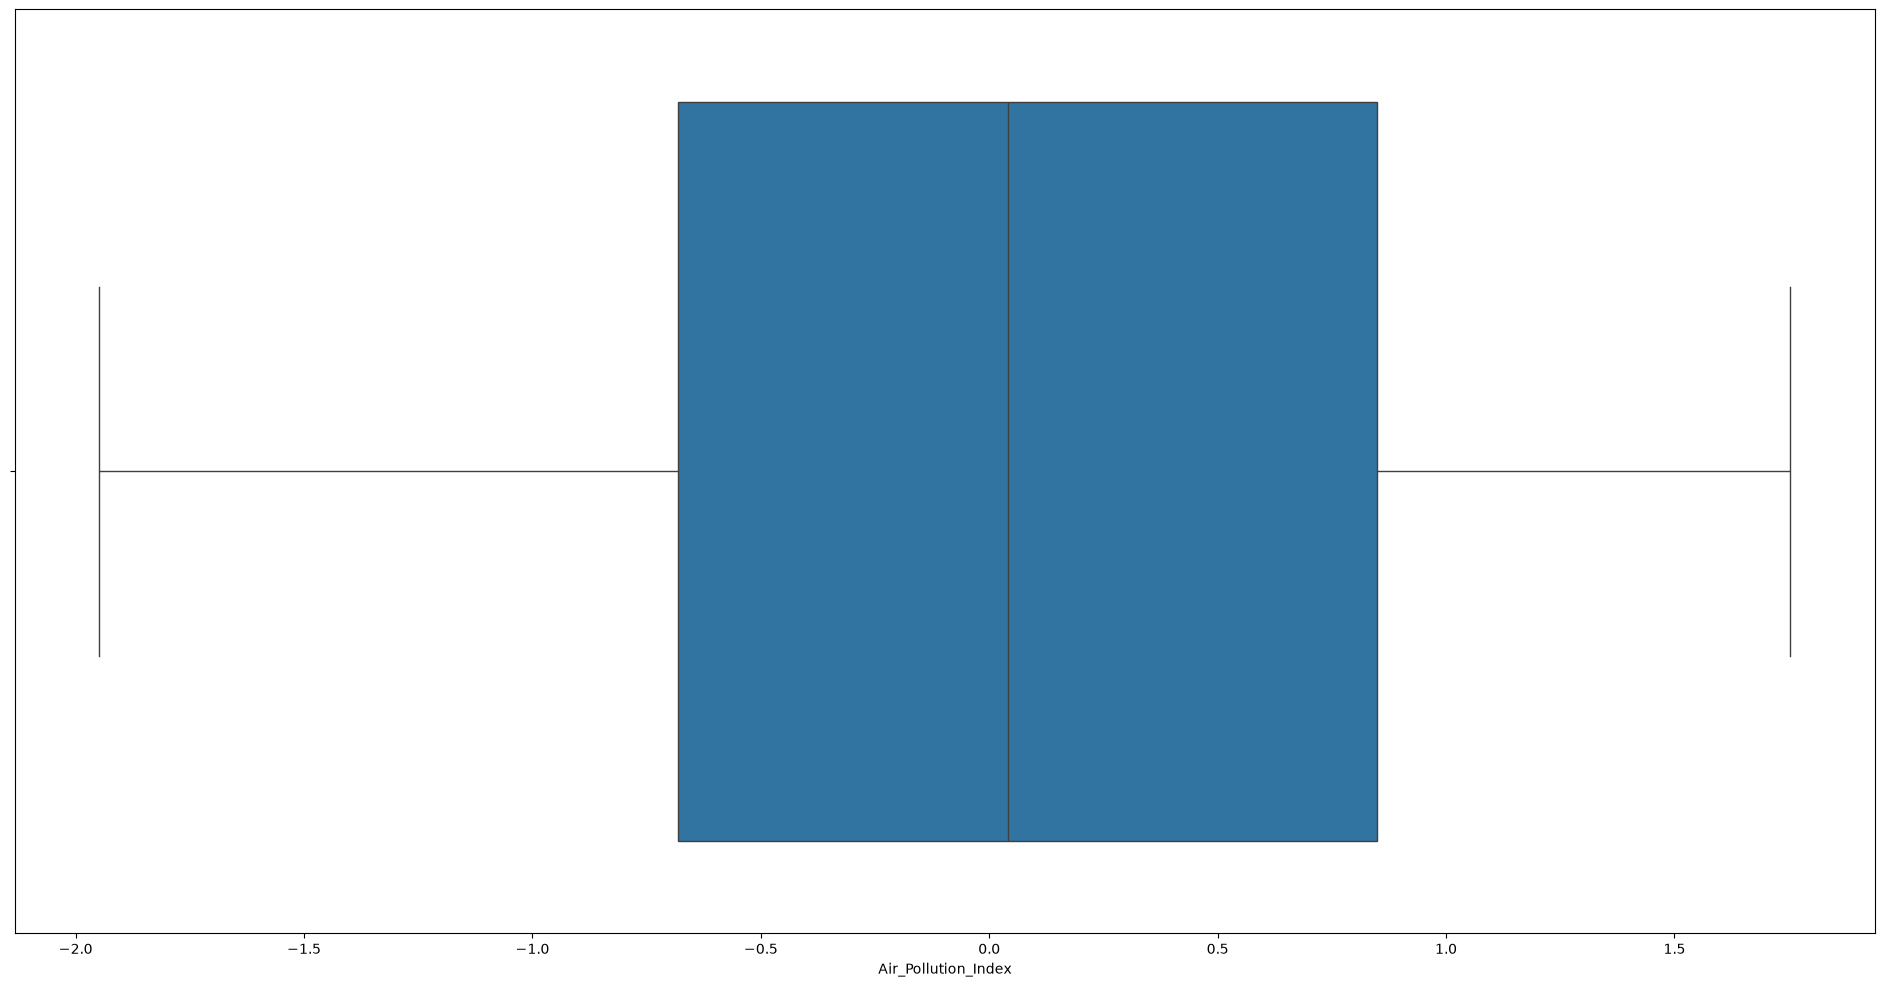

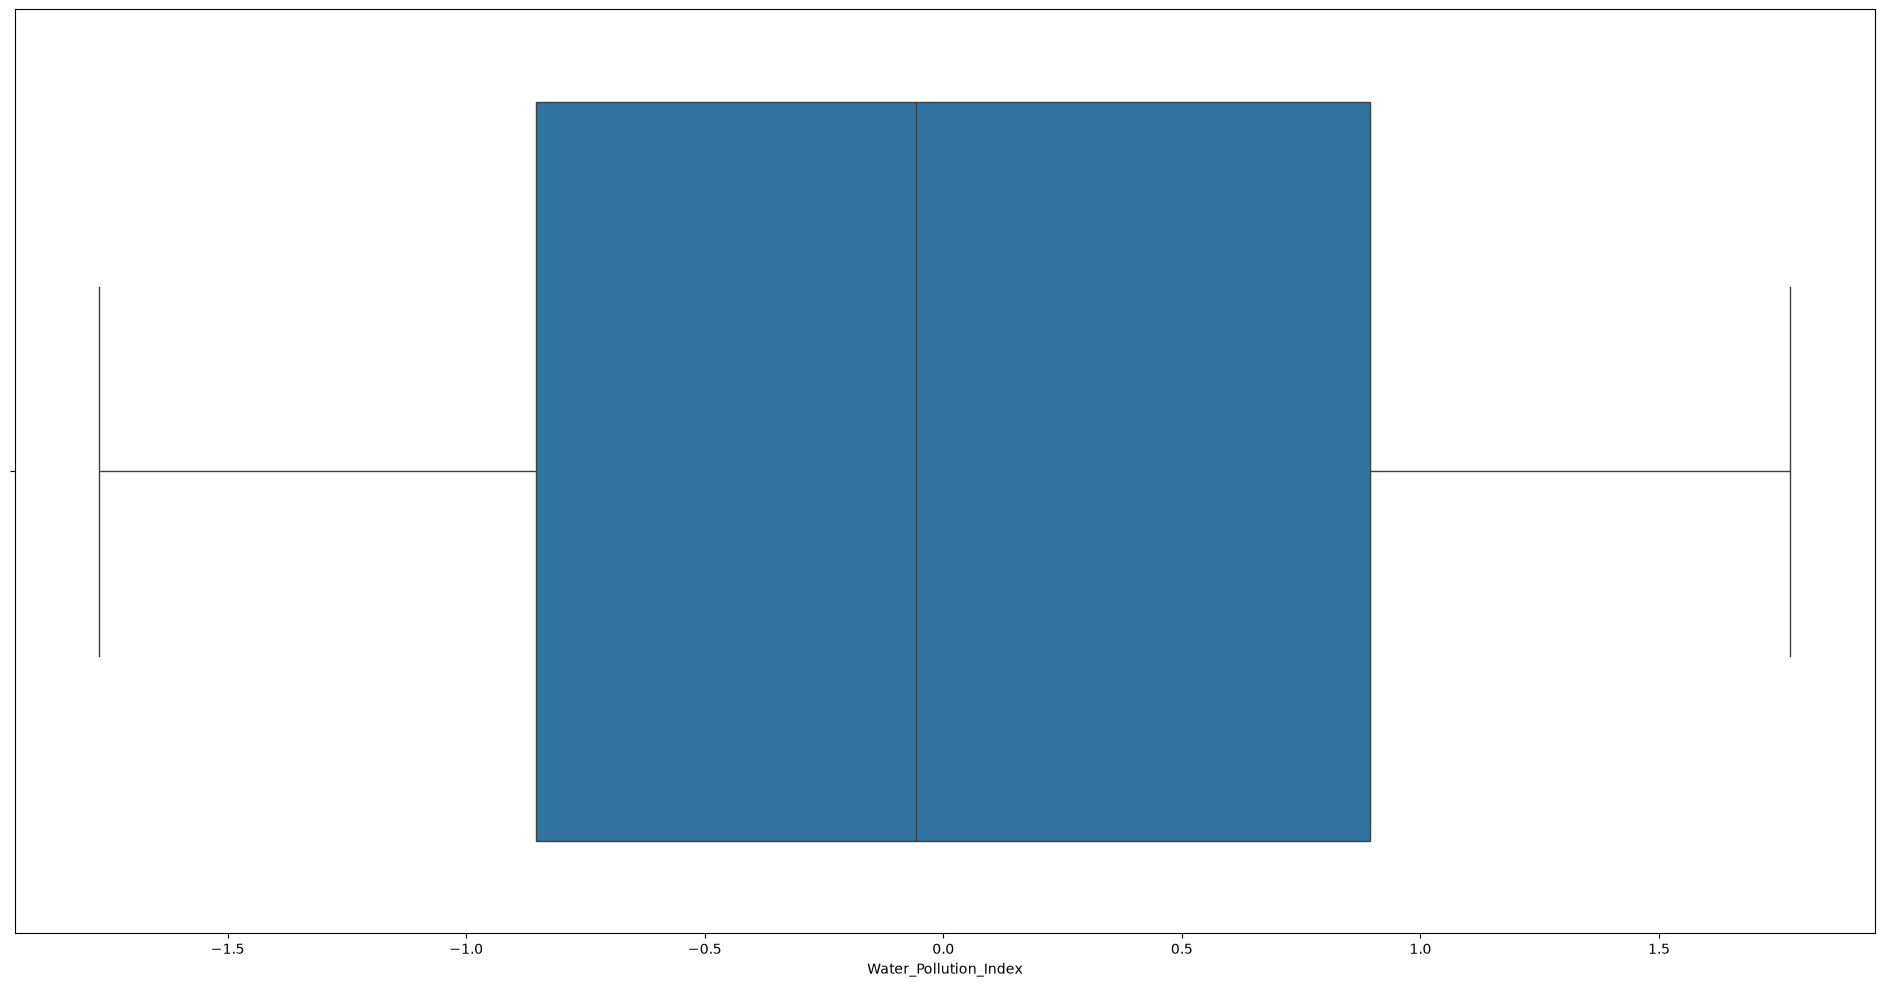

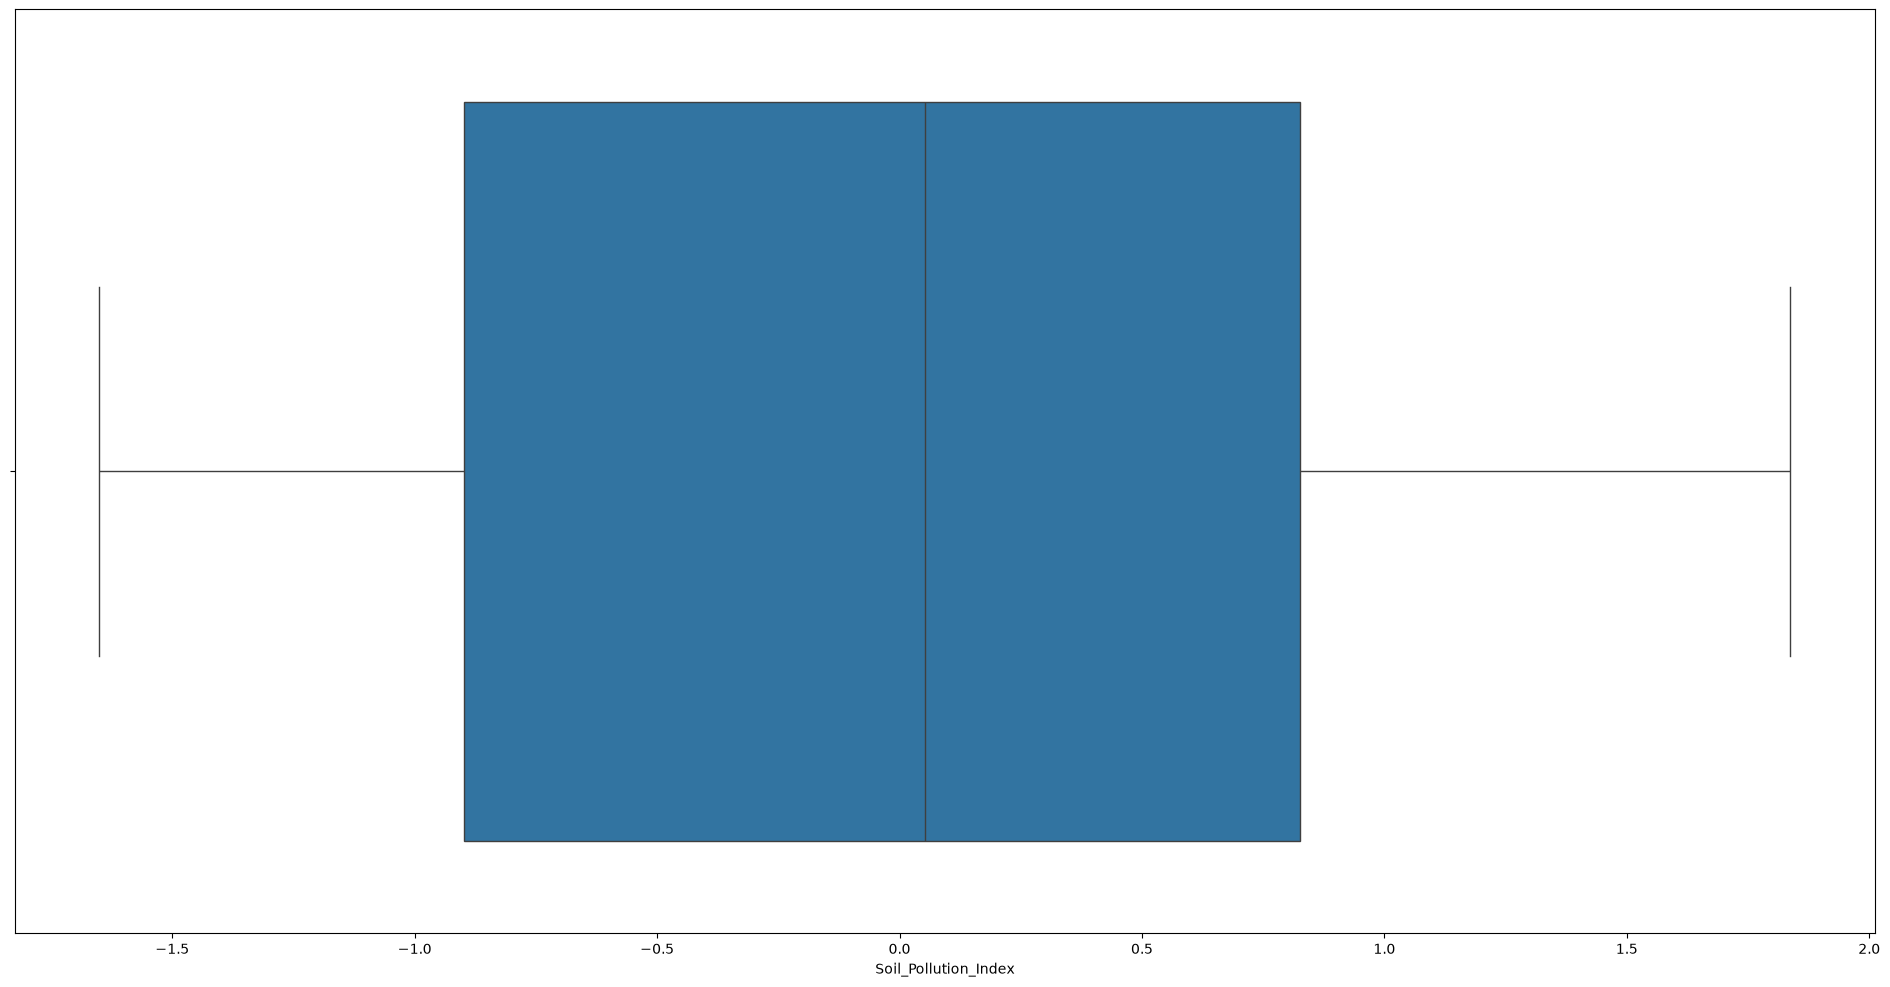

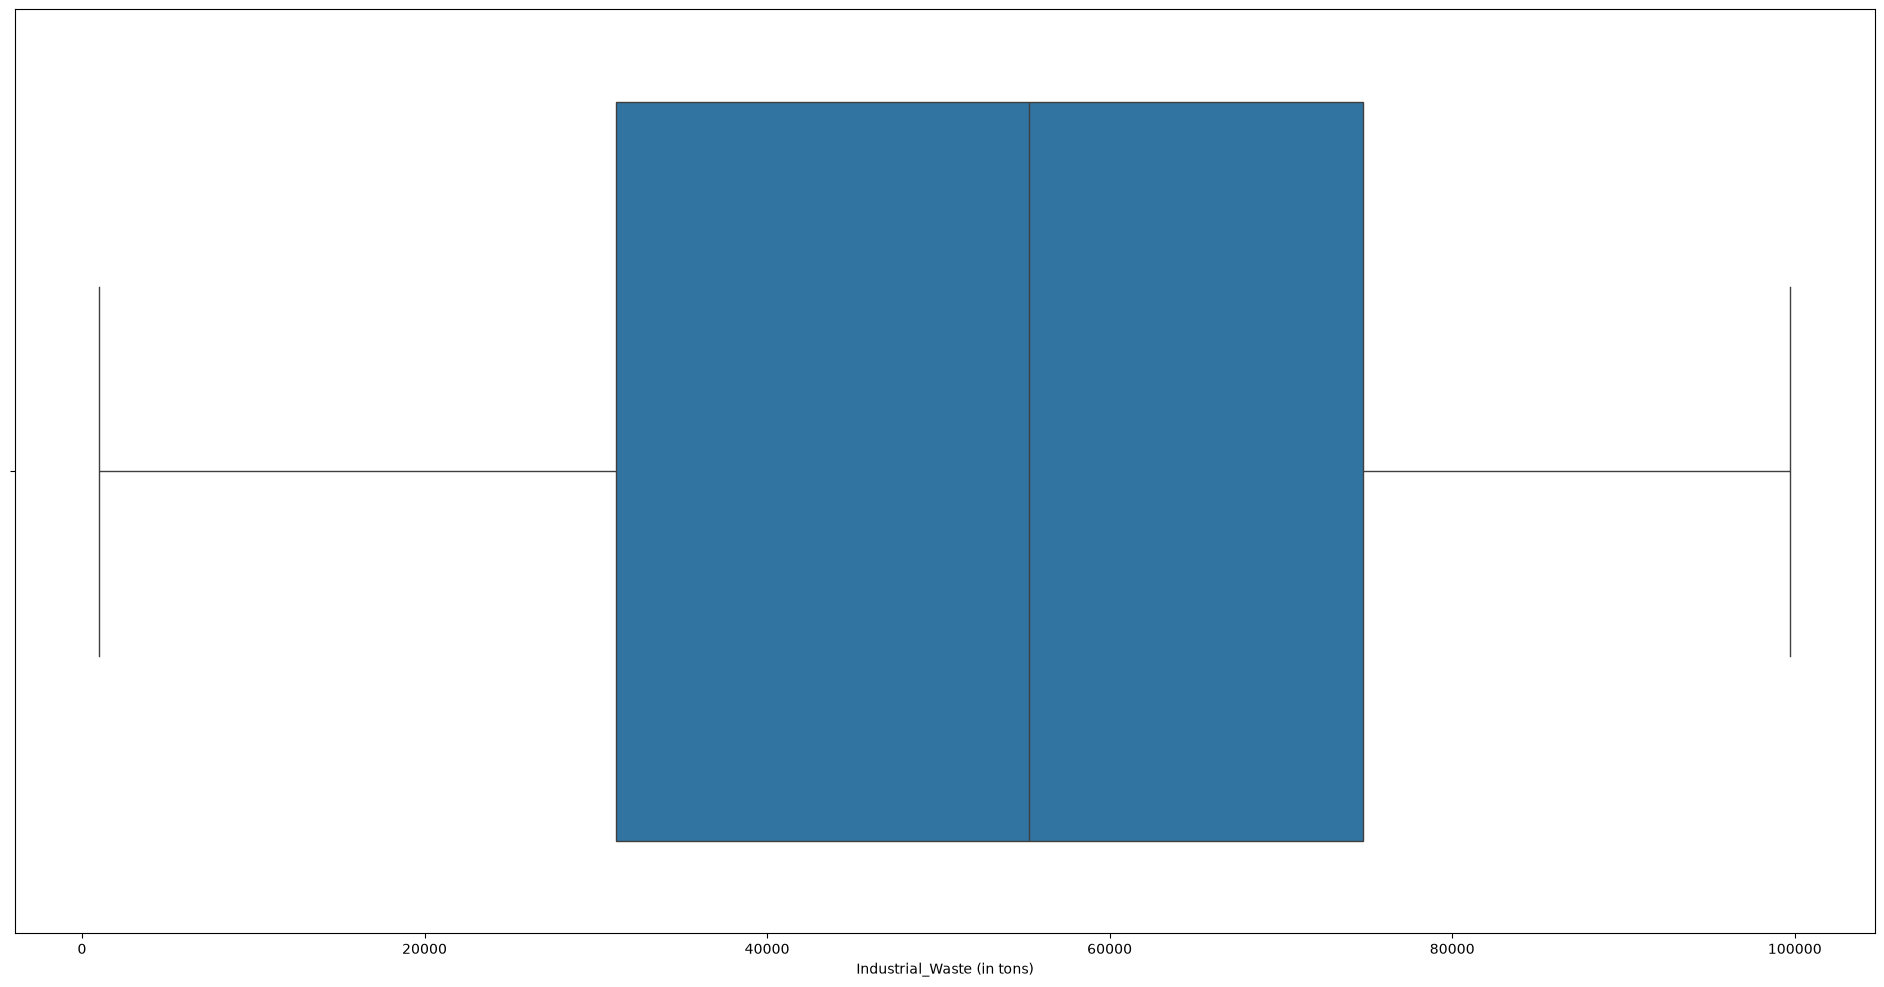

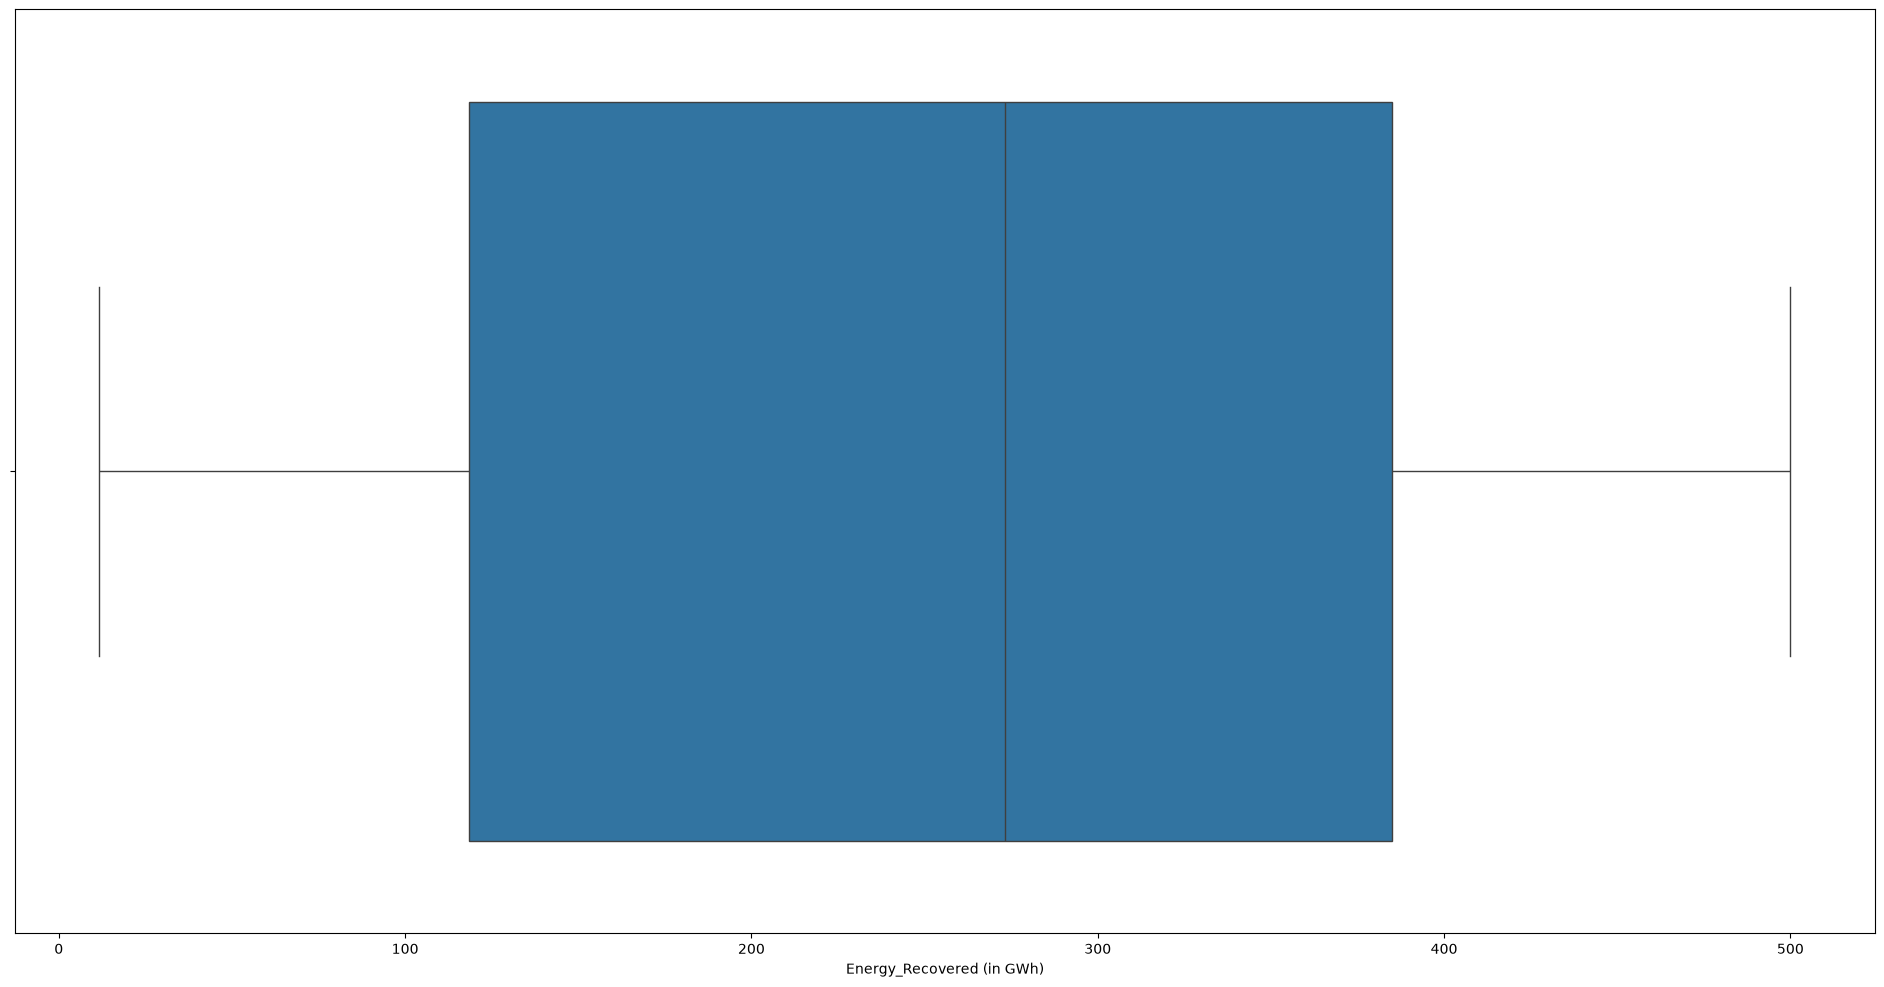

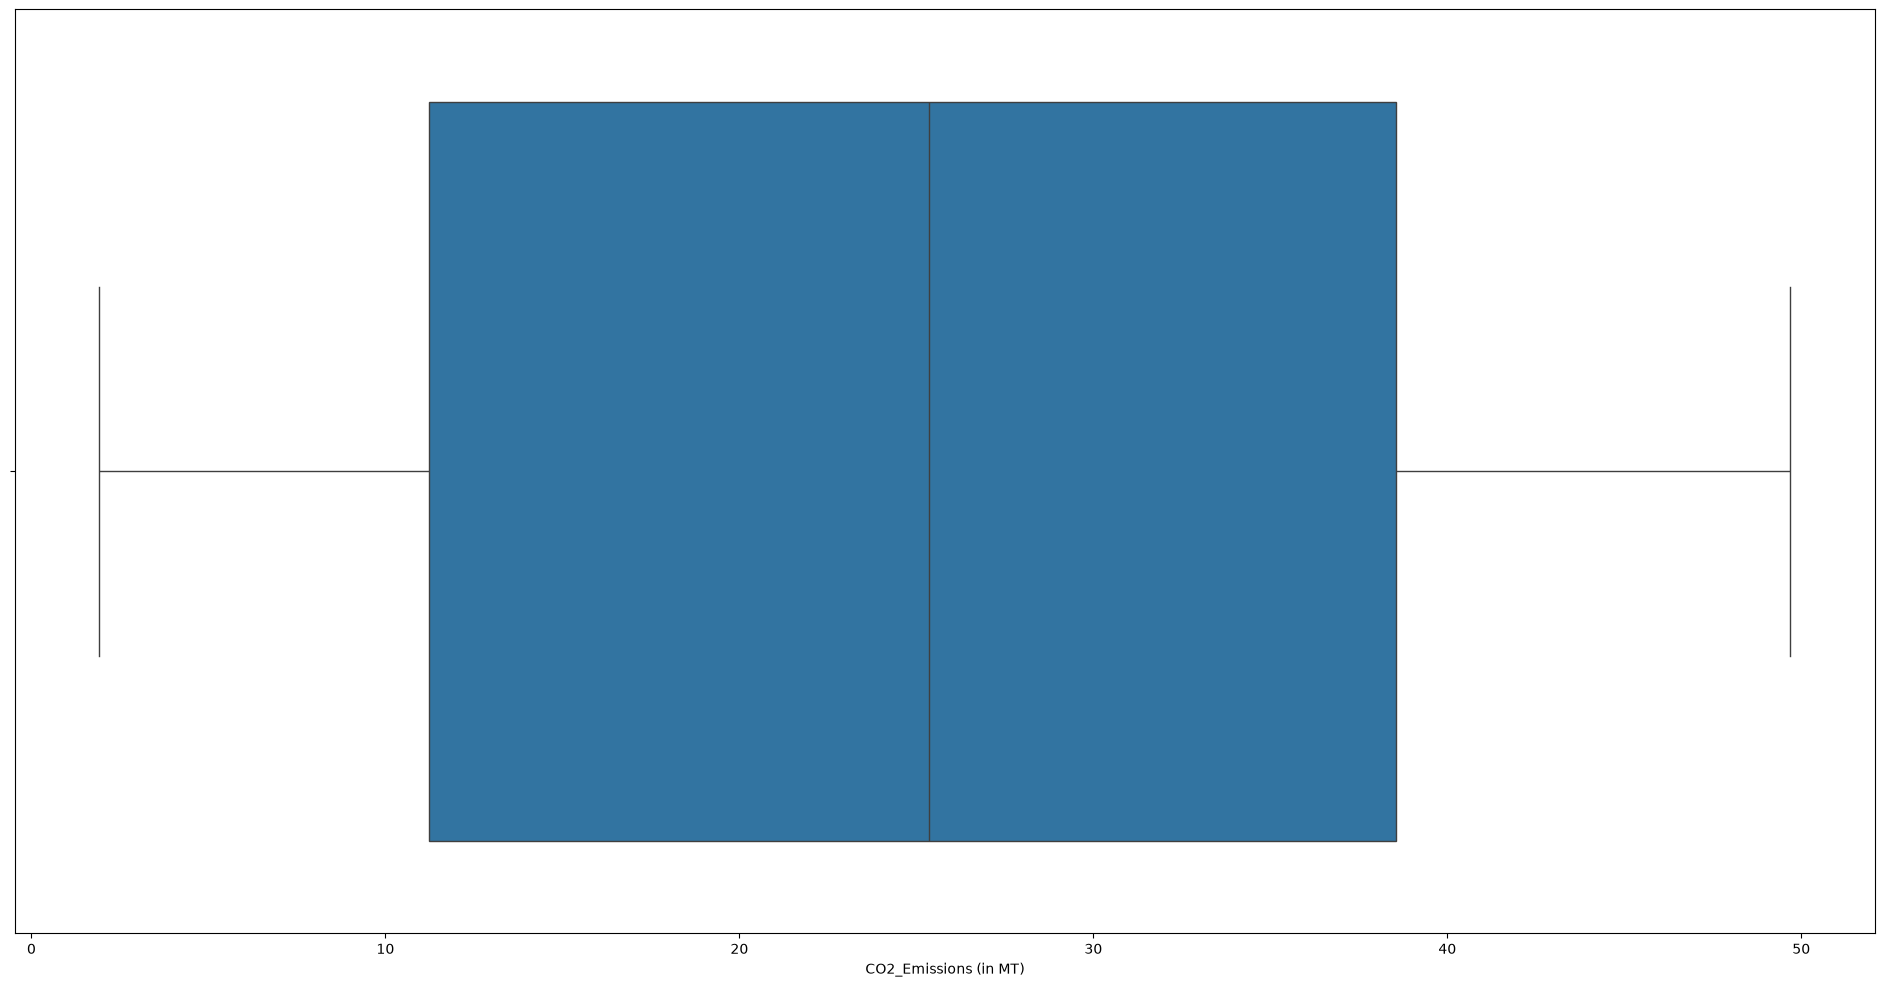

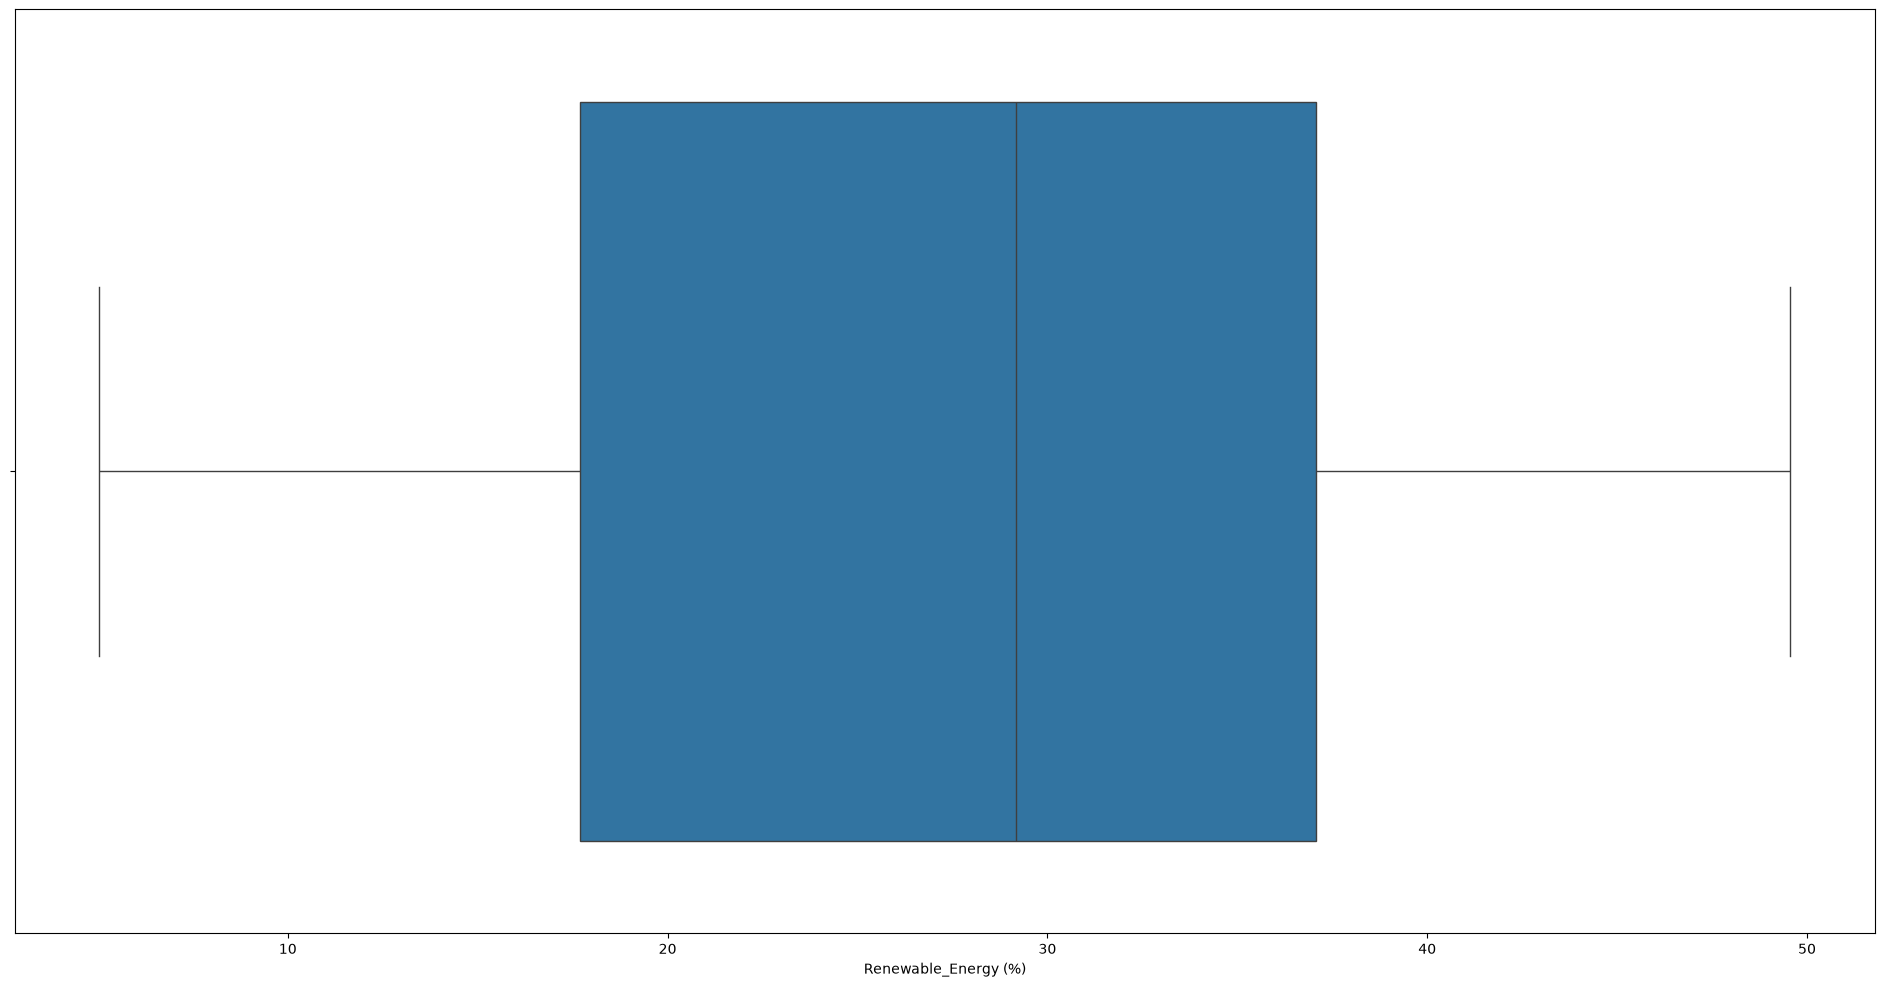

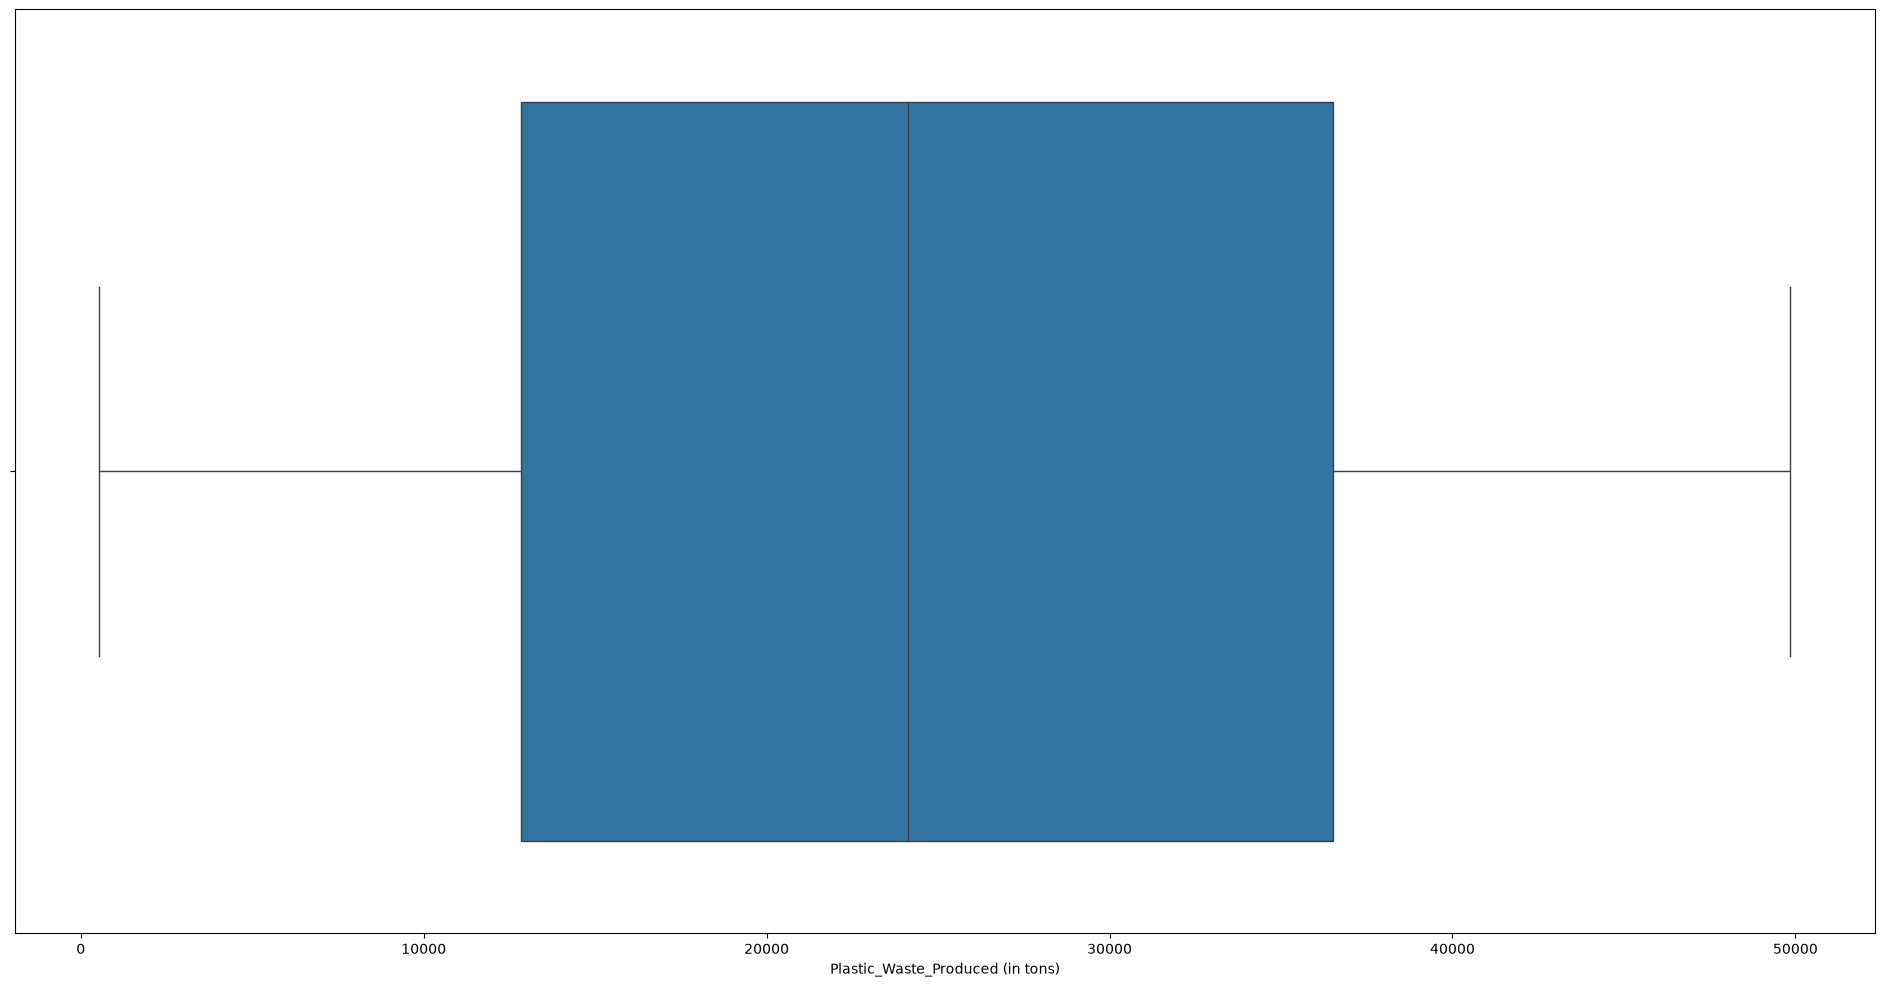

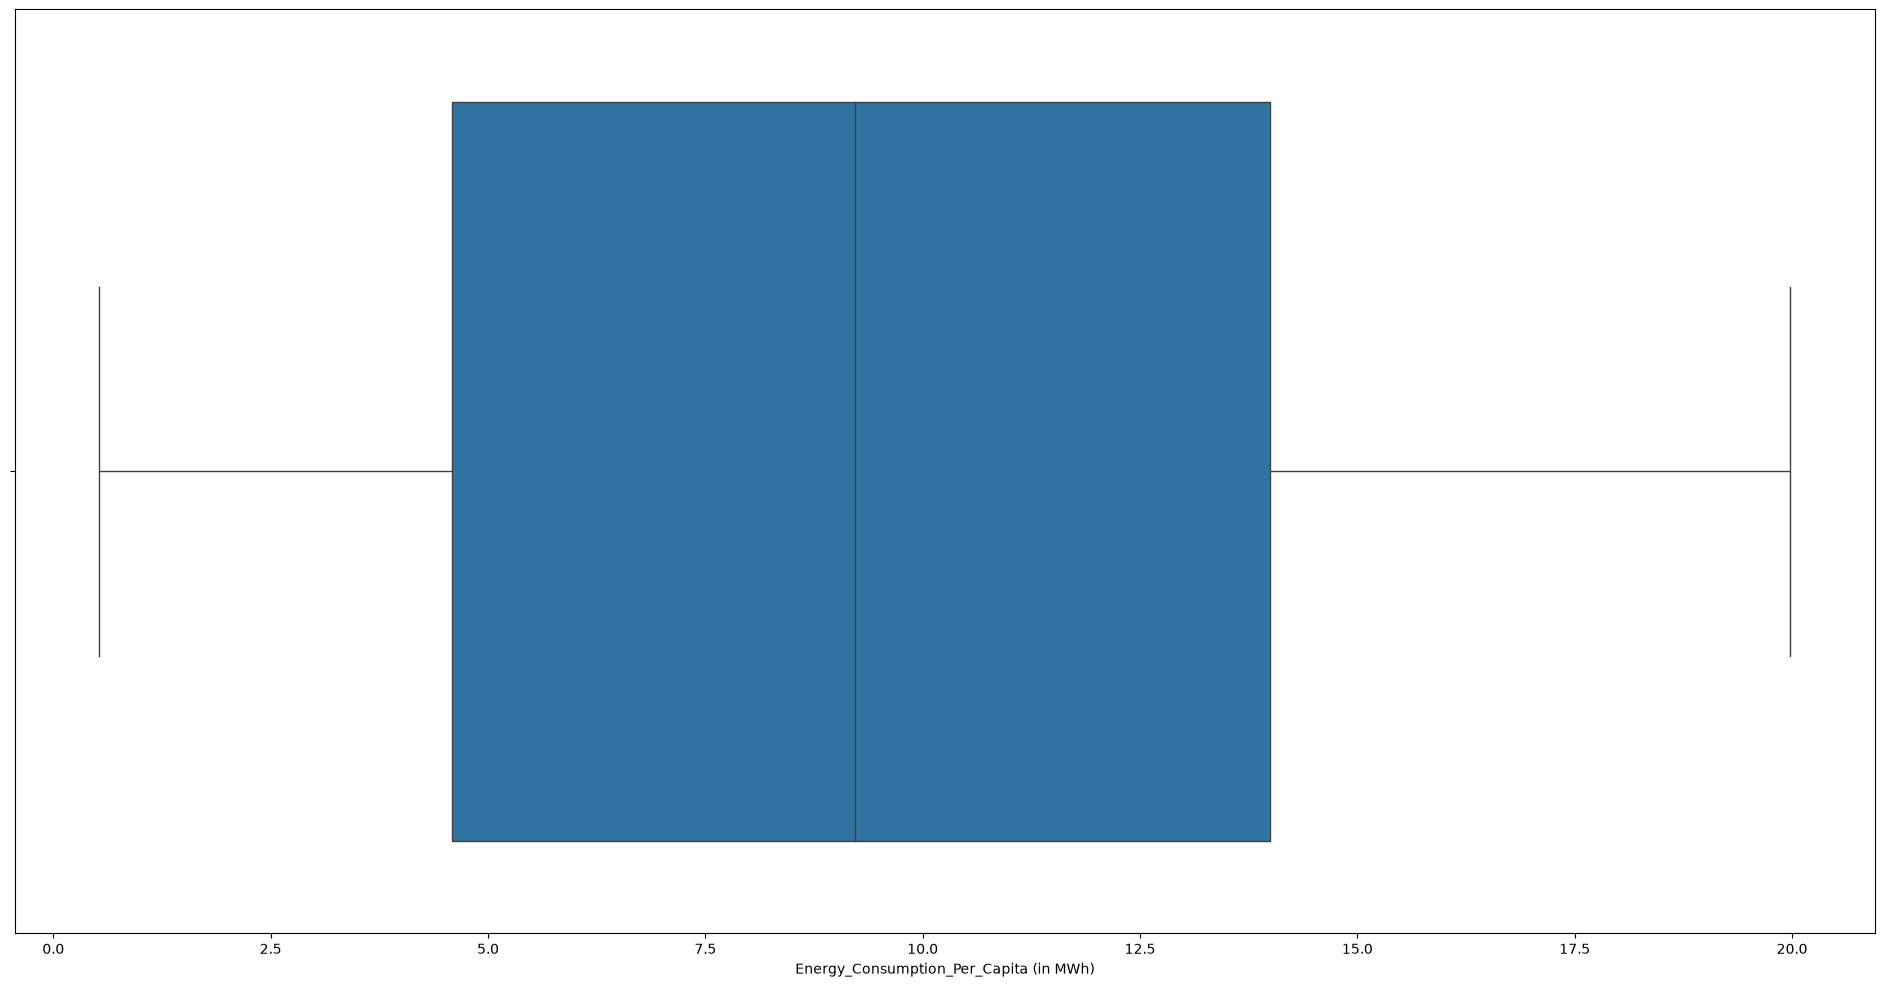

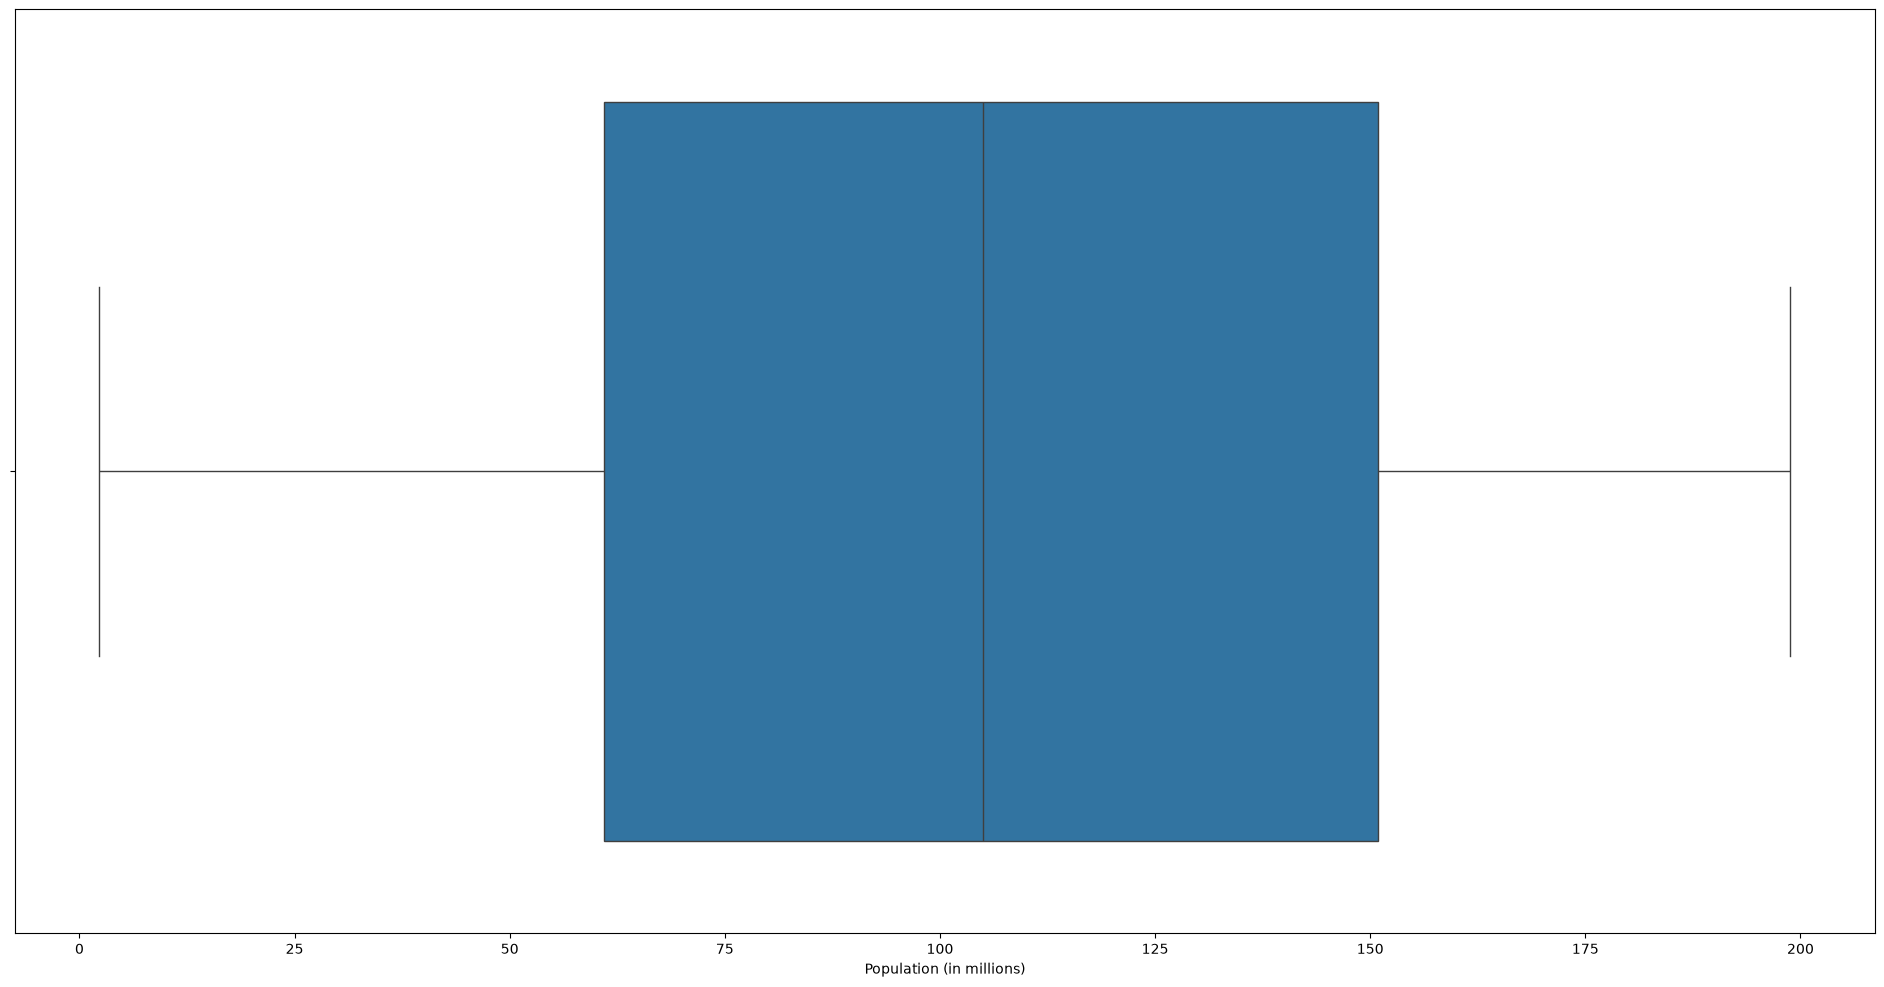

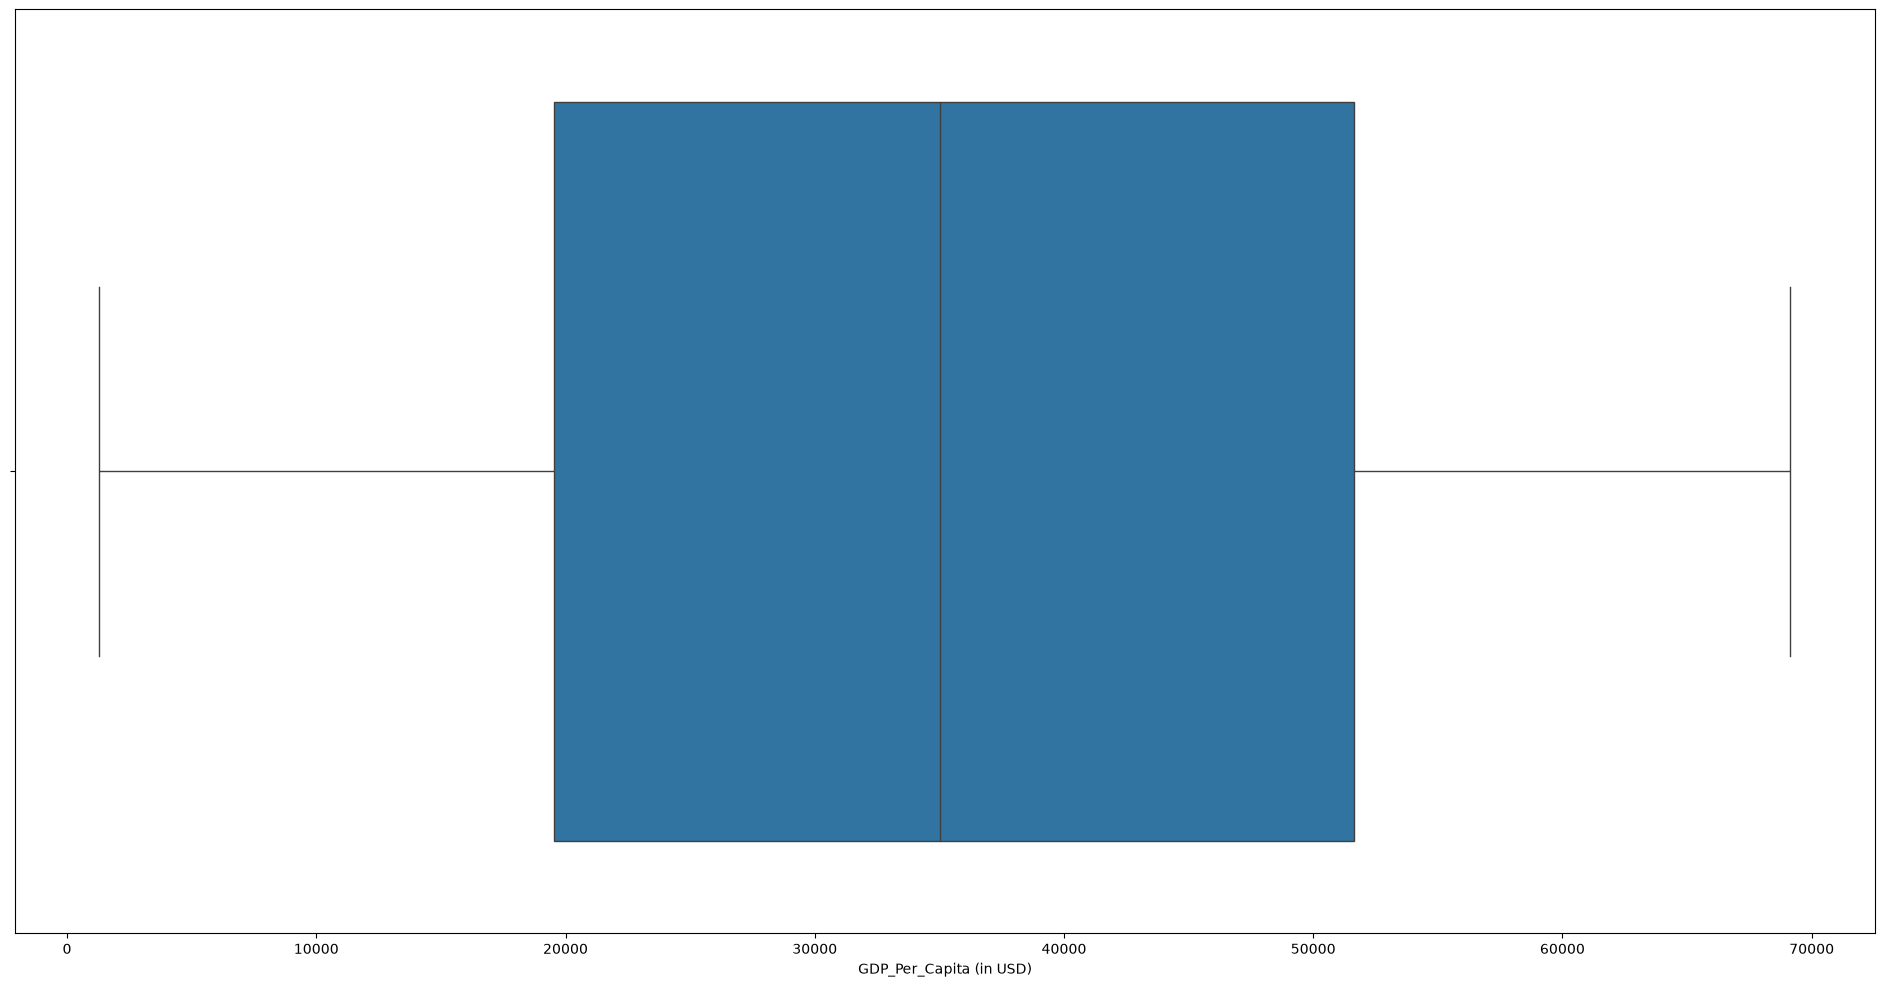

In [270]:
numeric_columns = df_new.select_dtypes(include='number').columns
for num_cols in numeric_columns:
    plt.figure(figsize=(24,12))
    sns.boxplot(x = df_new[num_cols] )

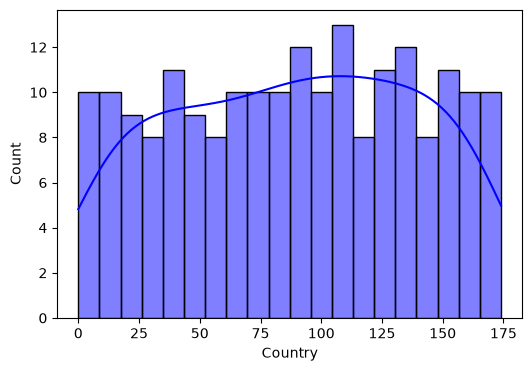

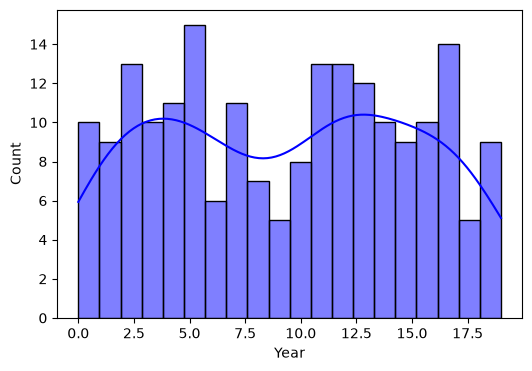

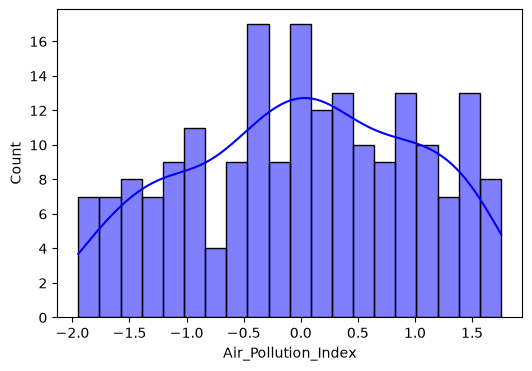

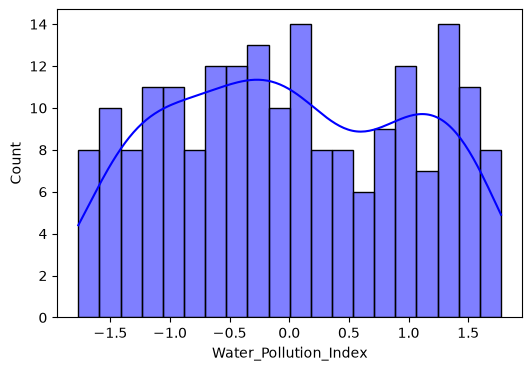

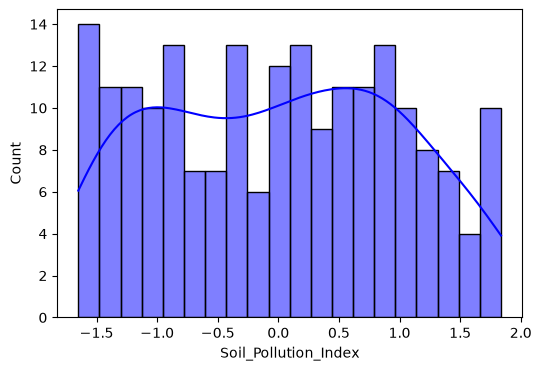

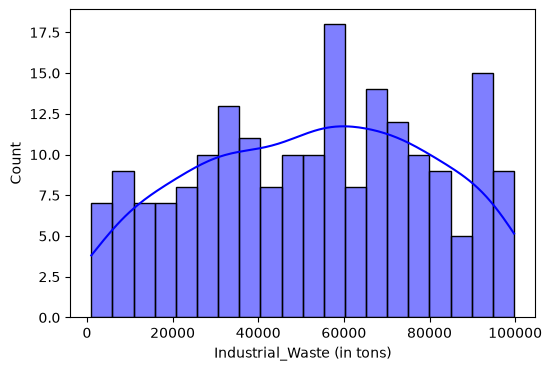

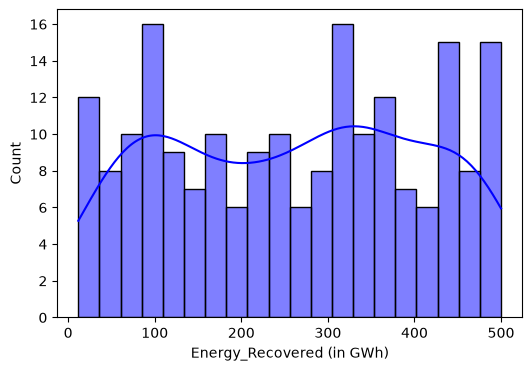

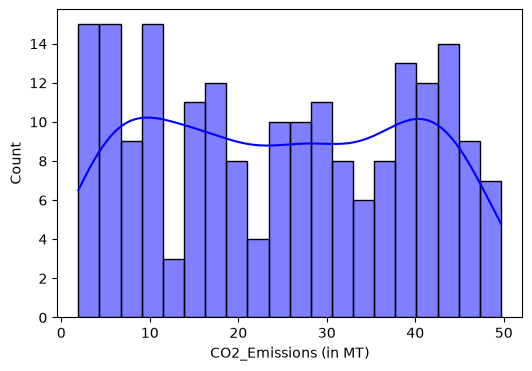

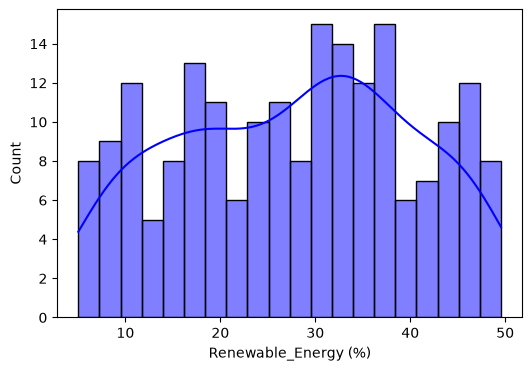

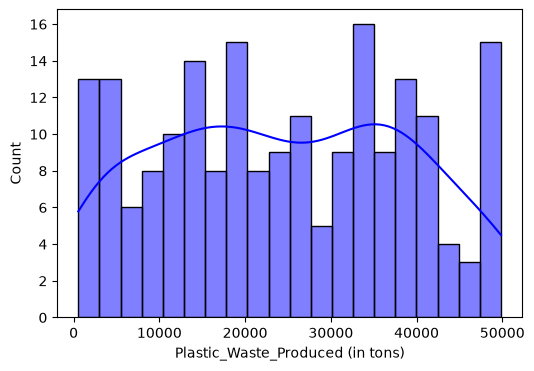

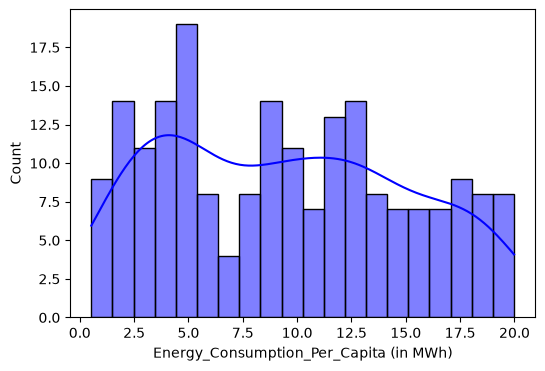

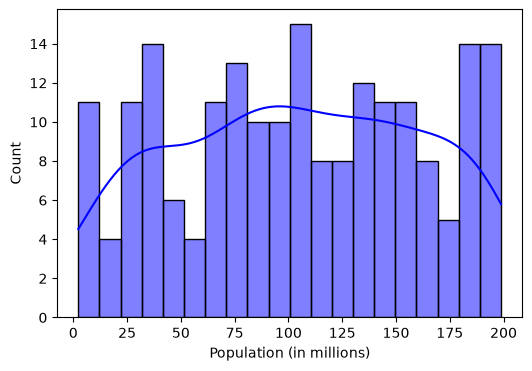

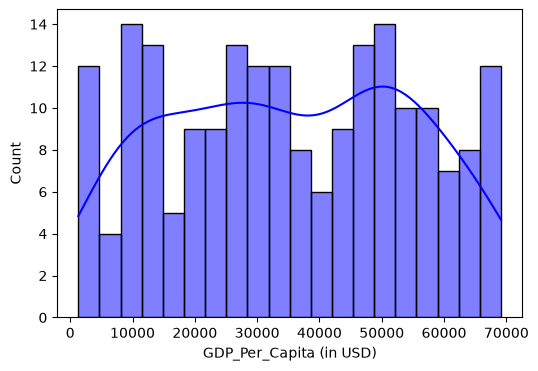

In [271]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_new[num_cols] ,kde = True,bins = 20 , color="blue"  )

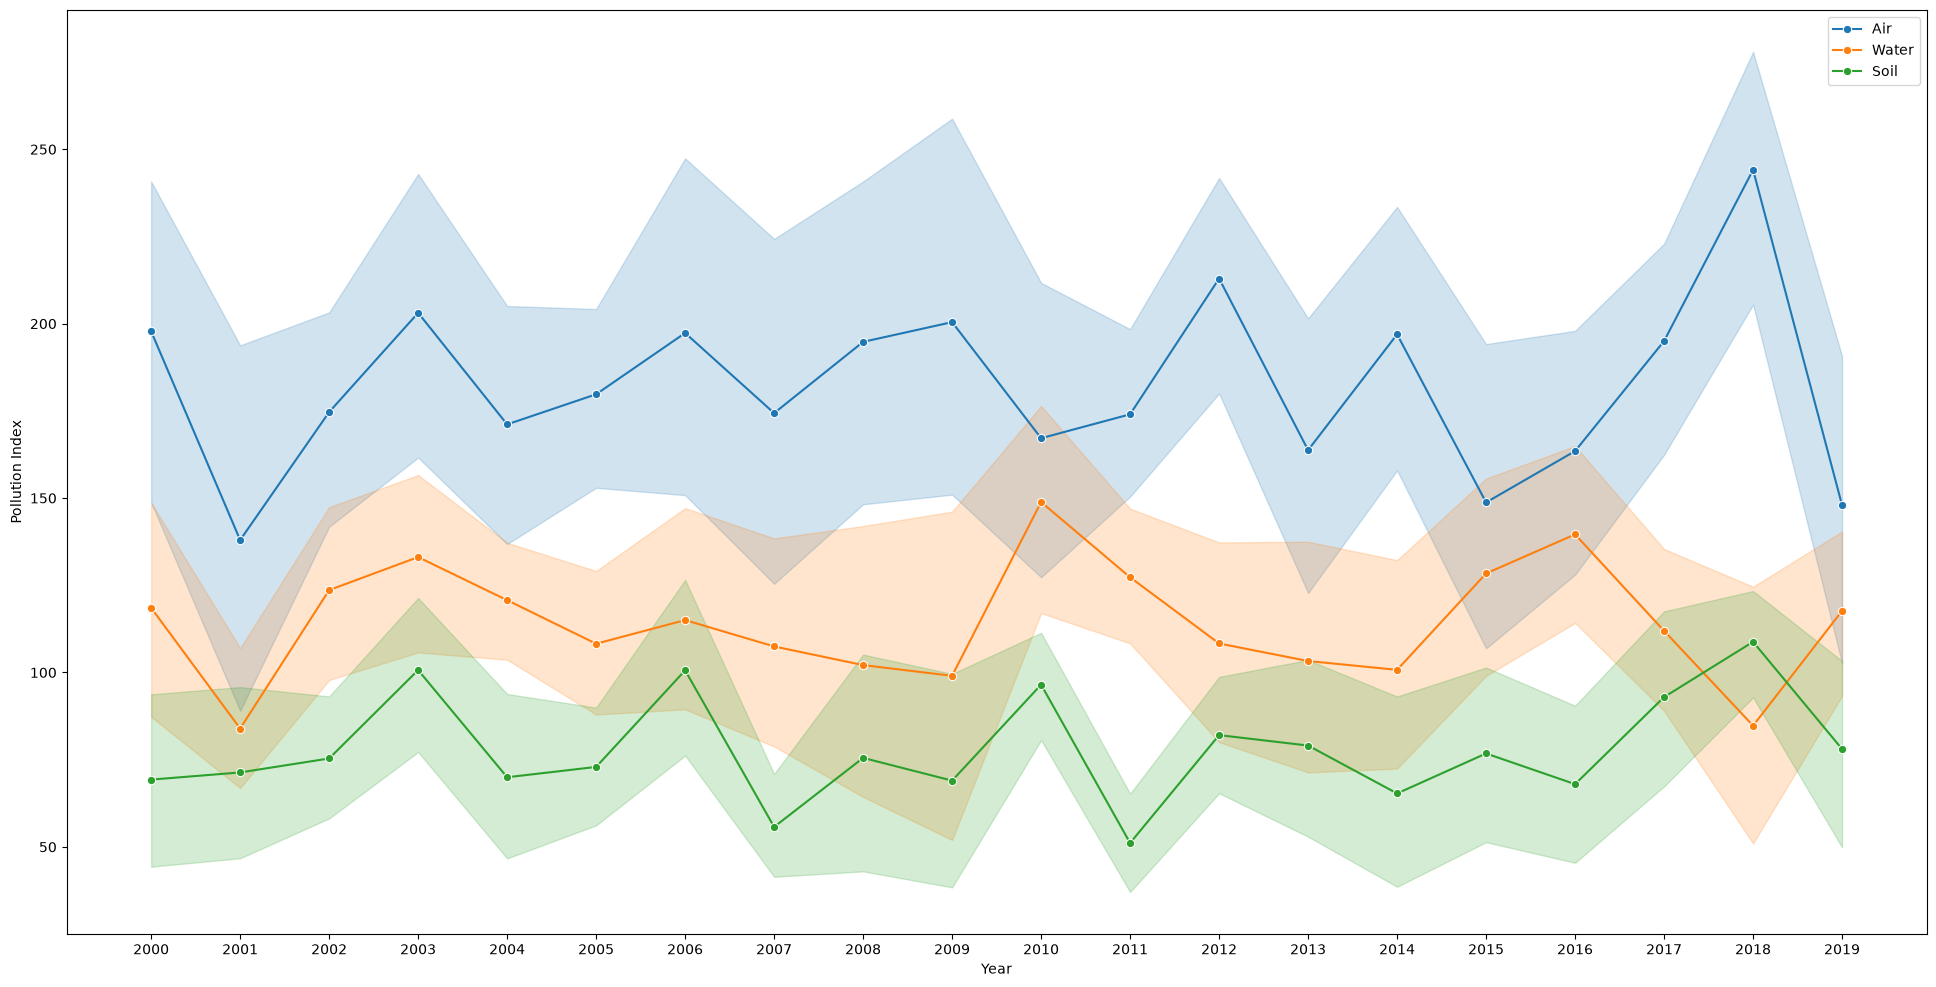

In [272]:
plt.figure(figsize=(24,12))

sns.lineplot(data=df,x='Year',y='Air_Pollution_Index',label='Air', marker='o')
sns.lineplot(data=df,x='Year',y='Water_Pollution_Index',label='Water', marker= 'o')
sns.lineplot(data=df,x='Year',y='Soil_Pollution_Index',label='Soil', marker ="o")

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Observation we get :
- Air Pollution (Blue Line): Generally fluctuating more, major peaks around 2003, 2006, 2009, 2012, and a maximum overall peak in 2018.

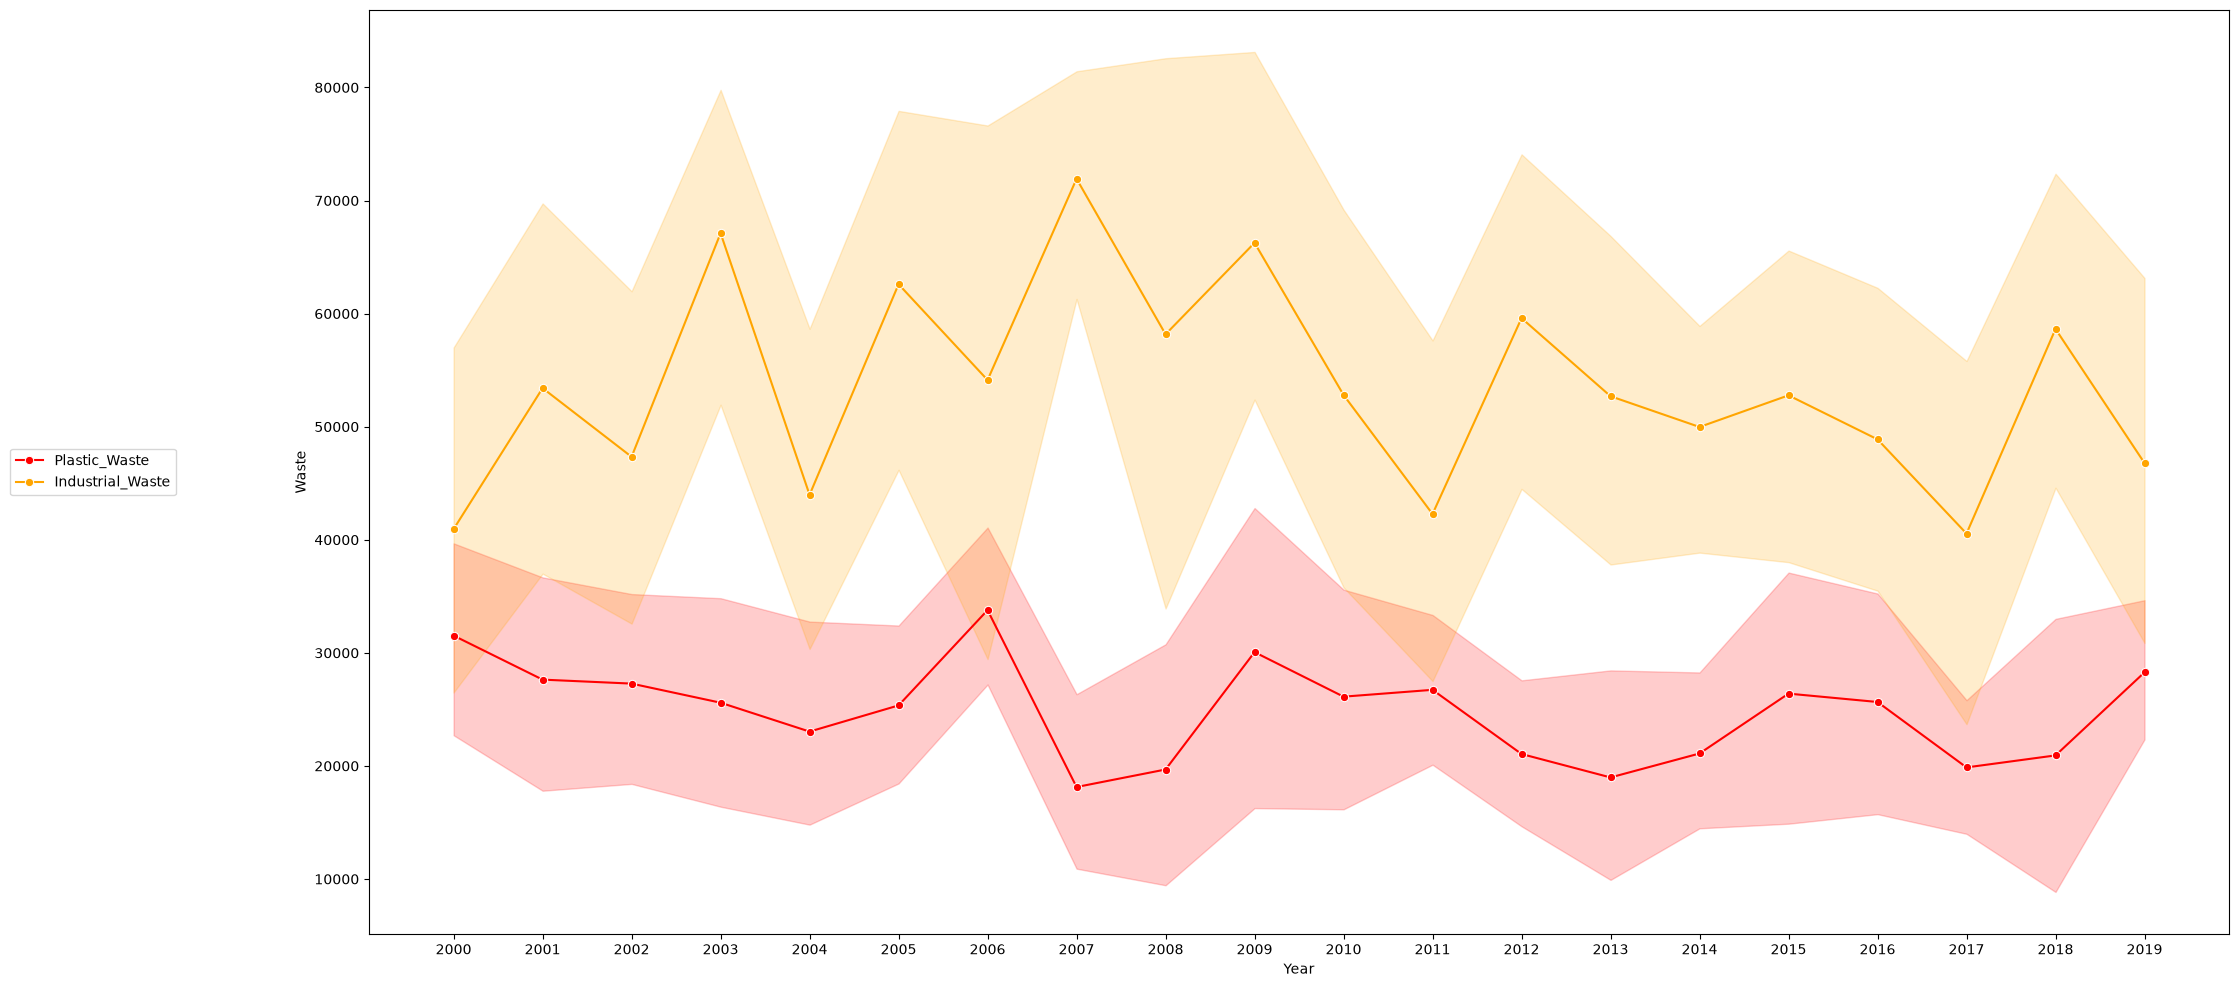

In [273]:
plt.figure(figsize=(24,12))


sns.lineplot(data=df,x='Year',y='Plastic_Waste_Produced (in tons)',label='Plastic_Waste', marker= 'o' , color='red')
sns.lineplot(data=df,x='Year',y='Industrial_Waste (in tons)',label='Industrial_Waste', marker ="o", color='orange')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Waste")

plt.legend(loc='center right', bbox_to_anchor=(-0.1, 0.5))
plt.show()


### Industrial Waste (Orange Line): Consistently remains significantly higher than plastic waste, fluctuating between roughly 40,000 and 72,000 units.

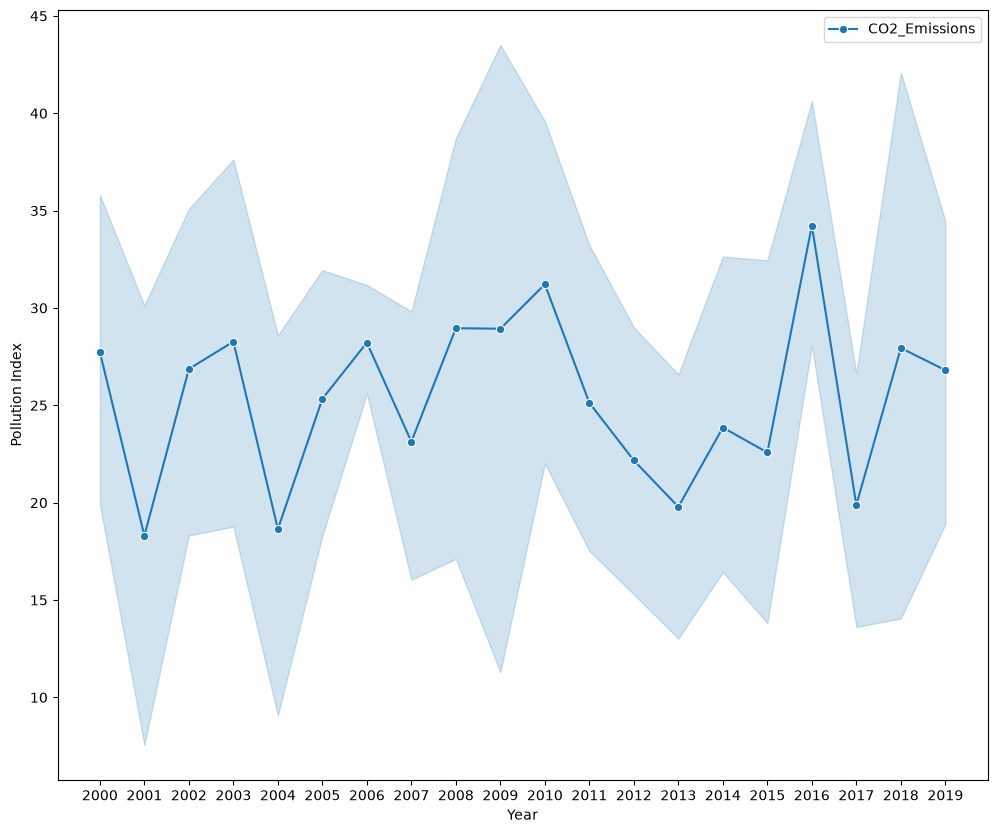

In [274]:
plt.figure(figsize=(12,10))

sns.lineplot(data=df,x='Year',y='CO2_Emissions (in MT)',label='CO2_Emissions', marker='o')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Values: $\text{CO}_2$ emissions fluctuate mostly between 18 and 34 units across the 20-year period.

In [275]:
df['Average_Pollution'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

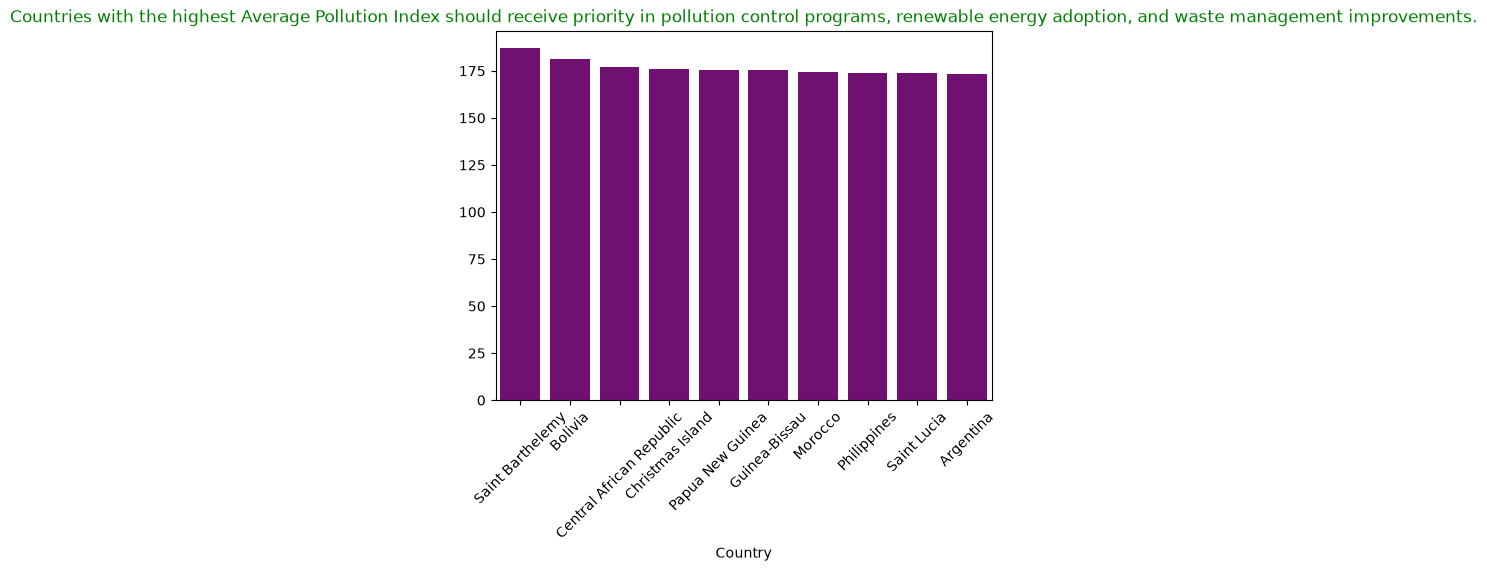

In [276]:
top10 = df.groupby('Country')['Average_Pollution'].mean().sort_values(ascending=False).head(10) # take help here :)

sns.barplot(x=top10.index, y=top10.values , color='purple')
plt.xticks(rotation=45)
plt.title("Countries with the highest Average Pollution Index should receive priority in pollution control programs, renewable energy adoption, and waste management improvements.", color="green")
plt.show()

Step 3 - Feature Engineering

In [277]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


In [278]:
yearly_trends = df.groupby("Year" , as_index=False)[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Average_Pollution",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Average_Pollution,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,128.530667,296.889000
1,2001,137.964444,83.933333,71.340000,97.745926,288.877778
2,2002,174.661538,123.617692,75.344615,124.541282,259.750769
3,2003,203.103000,133.080000,100.687000,145.623333,208.139000
4,2004,171.120909,120.719091,69.959091,120.599697,186.458182


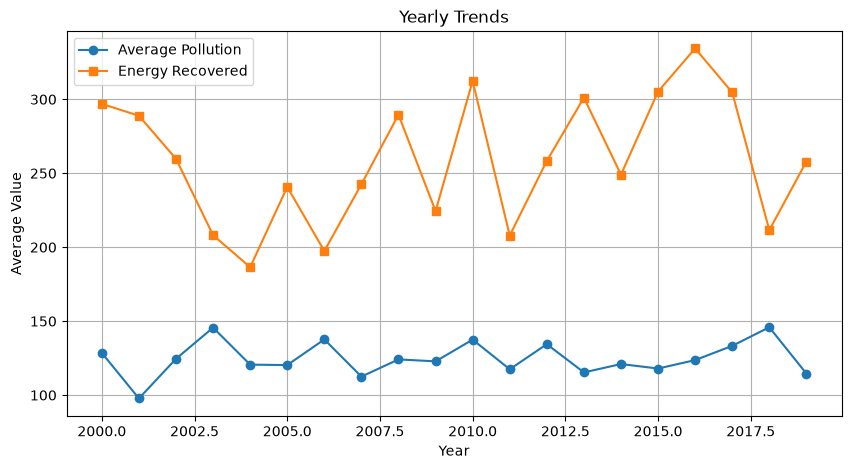

In [279]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends["Year"],
         yearly_trends["Average_Pollution"],
         marker='o',
         label="Average Pollution")

plt.plot(yearly_trends["Year"],
         yearly_trends["Energy_Recovered (in GWh)"],
         marker='s',
         label="Energy Recovered")

plt.xlabel("Year")
plt.ylabel("Average Value")
plt.title("Yearly Trends")
plt.legend()
plt.grid(True)

plt.show()

Energy_Consumption_Per_Capita (in MWh) is already given in the features , so no feature extraction

###  Step 4 - Linear Regression 


In [280]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [281]:

X = df[[
    "Air_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
]]
y = df['Energy_Recovered (in GWh)']

In [282]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [283]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [284]:
LinearModal = LinearRegression()

In [285]:
LinearModal.fit(X_train_scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -9.01, 5.52,-19.81, -4.19]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,265.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[13.42,12.8 ,12.35,11.97]"


In [286]:
y_pred = LinearModal.predict(X_test_scaled)

### Model Evaluation 

In [287]:
r2_c = r2_score(y_test, y_pred)
mes = mean_squared_error(y_test, y_pred)
mar = mean_absolute_error(y_test, y_pred)
print(r2_c)
print(mes)
print(mar)

-0.014782377689322557
24539.70752682382
141.35283321195448


### Observation : 

- The model performed poorly, as we have negative R² score.
- I think data/features are not good enough for linear regression. 


#  Logistic Regression

In [288]:
# take help here 
df["Pollution_Severity"] = pd.cut( 
    df["Average_Pollution"],
    bins=[0, 100, 170, float("inf")],
    labels=["Low", "Medium", "High"]
)

df["Pollution_Severity"].value_counts()

Pollution_Severity
Medium    145
Low        42
High       13
Name: count, dtype: int64

In [289]:
df.head(12)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution,Pollution_Severity
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,Medium
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,Low
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,Low
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667,Medium
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667,Medium
5,Croatia,2009,151.36,61.07,86.75,58079.80,136.26,33.39,39.49,12191.70,18.14,103.43,35092.93,99.726667,Low
6,Congo,2008,292.31,156.85,36.40,67774.76,199.71,35.29,26.17,9450.05,16.50,182.09,52050.07,161.853333,Medium
7,Central African Republic,2006,209.41,188.14,133.50,70552.49,499.98,29.04,47.64,26605.75,2.40,73.43,16491.90,177.016667,High
8,Swaziland,2007,269.63,62.33,71.19,43280.42,495.28,28.55,11.47,2137.98,12.42,11.26,55594.15,134.383333,Medium
9,Sri Lanka,2002,231.99,155.31,44.99,11306.14,472.63,48.35,45.31,49211.55,16.79,77.21,11627.65,144.096667,Medium


In [290]:
X = df[[
    "Air_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)"
]]

y = df["Pollution_Severity"]

In [291]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [292]:
print(y)

[2 1 1 2 2 1 2 0 2 2 2 2 2 2 2 2 1 2 1 2 2 2 1 2 2 2 2 1 2 2 1 2 2 2 0 2 2
 2 2 2 2 1 1 2 2 2 1 2 2 1 2 2 2 1 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 2
 2 1 2 0 2 1 2 2 2 2 2 2 2 1 1 2 2 1 2 2 0 2 2 1 1 2 2 2 2 0 2 2 2 2 2 2 1
 1 2 0 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 0 2 2 2 2 2 2 2 1 2 1 2
 2 2 1 2 0 2 2 2 2 1 0 1 2 2 1 1 1 1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 0 2 0 0 2
 2 1 2 1 2 2 1 1 2 2 1 2 2 2 2]


In [293]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [294]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [295]:
from sklearn.linear_model import LogisticRegression
LogisticModal = LogisticRegression(
    max_iter=1000,
    random_state=42
)

LogisticModal.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [296]:
y_pred = LogisticModal.predict(X_test)

### Model Evaluation 

In [297]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred)

0.75

### Observation : 

- The model performed good, as we have 75% score.
- The overall performance was okay, but using more features or better methods may improve the results.


In [298]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.60      0.38      0.46         8
           2       0.77      0.93      0.84        29

    accuracy                           0.75        40
   macro avg       0.46      0.44      0.44        40
weighted avg       0.68      0.75      0.70        40



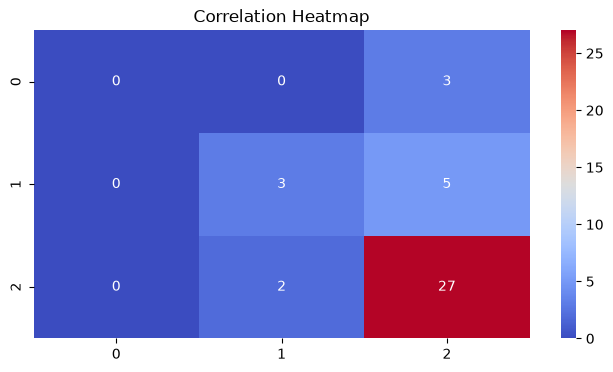

In [299]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 4))

plt.title("Correlation Heatmap")

sns.heatmap(cm, annot=True, cmap = "coolwarm")

plt.show()

###  Comparison

COMPARISION TABLE :

| Metric         | Linear Regression          | Logistic Regression           |
| -------------- | -------------------------- | ----------------------------- |
| **Goal**           | Predict Energy_Recovered (in GWh)         | Predict Pollution_Severity         |
| **Main Metric**   | R² Score                   | Accuracy                      |
| **Performance**   |-0.014          | 0.75             |
| **Relation** | Very Weak with feature  | Moderate with feature |


# Key Insights


1. Pollution levels vary significantly across countries, with Air, Water, and Soil Pollution Indices showing strong contributions to the overall pollution severity. Countries with consistently high pollution indices require immediate environmental interventions.

2. Energy recovery is positively influenced by factors such as industrial waste generation and renewable energy adoption, indicating that efficient waste-to-energy systems can improve sustainable energy production.

3. The Linear Regression model not effectively predicts energy recovery based on environmental and industrial factors.

4. The Logistic Regression model successfully classifies countries into Low, Medium, and High pollution severity categories, enabling easier identification of high-risk countries for environmental monitoring and policy planning.

5. The overall analysis highlights the importance of reducing CO₂ emissions, increasing renewable energy usage, and improving waste management practices to simultaneously reduce pollution levels and enhance energy recovery efficiency.